# Проект. Исследование стартапов

- Автор: Цветкова Анастасия Валерьевна
- Дата: 09.03.2026

## Введение

### Цель и задачи проекта

**Цель:** Провести исследовательский анализ исторических данных с целью выявить закономерности финансирования стартапов, результаты которого помогут финансовой компании, работающей с венчурными инвестициями, оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Задачи:**

Подготовить к работе датасет с информацией о компаниях, объёмах и типах привлечённых инвестиций, статистикой по возвратам средств, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий:

- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.

- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.

- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.

- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.

- Сравнить популярность и объёмы разных типов финансирования.

- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.

- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.

- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.

---

In [1]:
# загружаем необходимые для работы библиотеки
import pandas as pd
# import numpy as np

# библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# библиотека для расчёта коэффициента корреляции phi_k
try:
    from phik import phik_matrix
except:
    %pip install phik

# скрываем отображение ненужных предупреждений
# import warnings
# warnings.filterwarnings("ignore")  

In [2]:
# добавим настойки, чтобы отображались все столбцы датафрейма 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

---
Загрузим все данные по проекту.

---

In [3]:
# загружаем основной датафрейм
investments = pd.read_csv('datasets/cb_investments.zip', sep=';', low_memory=False)
df = pd.DataFrame(investments)

In [4]:
# загружаем дополнительный датафрейм
returns = pd.read_csv('datasets/cb_returns.csv')
df_returns = pd.DataFrame(returns)

---
Выведем информацию, которая необходима для принятия решений о предобработке.

---

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.tail()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


**Выводы:**

В основном датасете 54294 строк и 40 столбцов. Пропуски есть во всех строках! Максимальное число не пропущенных значений в столбцах – 49438 (в последних строках стаблицы все строки в пропусках, нужно проверить).

В дополнительном датасете 15 строк и 14 столбцов. Пропусков нет, данные и их типы соответствуют описанию. Названия столбцов корректны.

В основном датасете в названии столбцов заметны лишние пробелы (market, funding_total_usd). Нужно привести названия к единому виду.

По типу данных замечены несоответствия:

- Должны быть числовыми – funding_total_usd.
- Должны быть датой – founded_at, first_funding_at, mid_funding_at, last_funding_at.
- Могут быть целочисленными (но там есть пропуски) – funding_rounds, participants, founded_year.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах, все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле, и приведем их к единому аккуратному стилю.

---

In [10]:
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'], dtype='object')

In [11]:
df_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'], dtype='object')

Приведем названия столбцов основного датафрейма к единому стилю и уберем лишние пробелы (со столбцами дополнительного датафрейма все в порядке):

In [12]:
new_columns = df.columns
new_columns = pd.Series(new_columns)
new_columns = new_columns.str.lower()
new_columns = new_columns.str.strip()

In [13]:
df.columns = new_columns
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'], dtype='object')

---
Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

---

In [14]:
df['funding_total_usd']

0         9,00,00,000 
1           20,00,000 
2           90,00,000 
3           77,00,000 
4            5,40,000 
             ...      
54289              NaN
54290              NaN
54291              NaN
54292              NaN
54293              NaN
Name: funding_total_usd, Length: 54294, dtype: object

In [15]:
# df['funding_total_usd'].info()

In [16]:
ftu_before = df['funding_total_usd'].notna().sum()
ftu_before

np.int64(49438)

In [17]:
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'].str.replace(',', ''), errors='coerce') 

In [18]:
df['funding_total_usd']

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
54289           NaN
54290           NaN
54291           NaN
54292           NaN
54293           NaN
Name: funding_total_usd, Length: 54294, dtype: float64

In [19]:
ftu_after = df['funding_total_usd'].notna().sum()
ftu_after

np.int64(40907)

In [20]:
# df['funding_total_usd'].info()

Посчитаем, сколько строк преобразовалось в пропуски и сколько действительно пропущенных значений в столбце `funding_total_usd`:

In [21]:
print(f'В пропуски преобразовалось {ftu_before - ftu_after} строк после изменения типа данных.')
print(f'Всего непропущенных значений в столбце funding_total_usd – {ftu_after}.')

В пропуски преобразовалось 8531 строк после изменения типа данных.
Всего непропущенных значений в столбце funding_total_usd – 40907.


---
Проверим и обработаем типы данных в столбцах, которые хранят значения даты и времени.

---

In [22]:
df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].head()

,founded_at,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,2014-01-06,NaN,2014-01-06
1,1785-01-01,2014-05-15,NaN,2014-05-15
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,2014-01-14,NaN,2014-01-14


In [23]:
df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   founded_at        38554 non-null  object
 1   first_funding_at  49438 non-null  object
 2   mid_funding_at    30288 non-null  object
 3   last_funding_at   49438 non-null  object
dtypes: object(4)
memory usage: 1.7+ MB


При попытке преобразовать тип данных для столбцов с датами появилась ошибка: дата основания первой в таблице компании (Harvard University) – founded_at='1636-09-08' – выходит за рамки допустимого диапазона дат для формата `datetime64[ns]`, где минимальная дата – это '1677-09-21'. Для того, чтобы выполнить данное преобразование, придется заменить данную дату пропуском.

In [24]:
df[df['founded_at'] < '1677-09-21']

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
for column in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df[column] = pd.to_datetime(df[column], format='%Y-%m-%d', errors='coerce') 

In [26]:
df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].head()

,founded_at,first_funding_at,mid_funding_at,last_funding_at
0,NaT,2014-01-06,NaT,2014-01-06
1,1785-01-01,2014-05-15,NaT,2014-05-15
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,2014-01-14,NaT,2014-01-14


In [27]:
df[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   first_funding_at  49428 non-null  datetime64[ns]
 2   mid_funding_at    30288 non-null  datetime64[ns]
 3   last_funding_at   49432 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 1.7 MB


---
В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

---

In [28]:
df_returns = df_returns.set_index('year')

In [29]:
df_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


---
Проверим и обработаем текстовые данные.

---

In [30]:
df_len_before = df.shape[0]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Удалим строки, которые не содержат данных (NaN во всех столбцах):

In [31]:
df = df.dropna(how='all')

In [32]:
df_len_after = df.shape[0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49438 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month        

Удалили 4856 пустых строк.

In [33]:
df[df['name'].isna()].T

,27212
name,NaN
homepage_url,http://tellitin10.com
category_list,|Startups|
market,Startups
funding_total_usd,25000.0
status,closed
country_code,NaN
state_code,NaN
region,NaN
city,NaN


Удалим пропуск из столбца `name` (в этой строке в целом много пропусков и мало информации, можно удалить):

In [34]:
df = df.dropna(how='all', subset=['name'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49437 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45988 non-null  object        
 2   category_list         45476 non-null  object        
 3   market                45476 non-null  object        
 4   funding_total_usd     40906 non-null  float64       
 5   status                48123 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49437 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38552 non-null  datetime64[ns]
 13  founded_month        

Пропуски в текстовых столбцах остались в (везде, кроме `name`):
homepage_url, 
category_list, 
market, 
status, 
country_code, 
state_code, 
region, 
city, 
founded_month, 
founded_quarter.

In [36]:
# посчитаем процент строк с пропусками и отсортируем по убыванию
nan_perc = round(df.isna().mean() * 100, 2)
nan_perc.sort_values(ascending=False)

state_code              38.99
mid_funding_at          38.73
participants            38.36
founded_month           22.16
founded_quarter         22.16
founded_year            22.02
founded_at              22.02
funding_total_usd       17.26
city                    12.37
region                  10.66
country_code            10.66
market                   8.01
category_list            8.01
homepage_url             6.98
status                   2.66
first_funding_at         0.02
last_funding_at          0.01
round_a                  0.00
round_d                  0.00
round_b                  0.00
product_crowdfunding     0.00
round_c                  0.00
name                     0.00
round_e                  0.00
round_f                  0.00
post_ipo_debt            0.00
round_g                  0.00
secondary_market         0.00
venture                  0.00
post_ipo_equity          0.00
private_equity           0.00
grant                    0.00
angel                    0.00
debt_finan

---
Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

---

In [37]:
df.duplicated().sum()

np.int64(0)

Полных (явных) дубликатов не обнаружено. Будем проверять неявные.

In [38]:
df['name'].nunique()

49350

В поле `name` еще до предобработки значений число уникальных (49350) меньше, чем всего строк (49438). Но это может быть нормально, если разные компании имеют одинаковое название. Проверим.

In [39]:
df = df.copy() # делаем копию датафрейма, чтобы убрать SettingWithCopyWarning

df['name'] = df['name'].str.lower().str.strip()
df['name'].nunique()

49331

In [40]:
df.duplicated().sum()

np.int64(0)

После преобразования названий уникальных значений стало на 19 штук меньше. Но полных дубликатов не появилось.

In [41]:
df[df.duplicated(subset=['name'], keep=False)].sort_values(by='name')

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
10350,adometry by google,NaN,|Advertising|Analytics|Displays|Software|,Software,450000.0,acquired,NaN,NaN,NaN,NaN,1.0,NaN,2006-01-01,2006-01,2006-Q1,2006.0,2010-01-12,NaT,2010-01-12,0.0,0.0,0.0,0.0,0.0,0.0,450000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8545,adometry by google,http://www.adometry.com,|Displays|Analytics|Software|Advertising|,Software,29125000.0,acquired,USA,TX,Austin,Austin,4.0,NaN,2005-01-01,2005-01,2005-Q1,2005.0,2007-02-07,NaT,2012-12-28,0.0,29125000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000000.0,10025000.0,6000000.0,8100000.0,0.0,0.0,0.0,0.0
25689,aps,NaN,|Real Estate|,Real Estate,NaN,operating,USA,GA,Macon,Griffin,1.0,0.0,2011-03-31,2011-03,2011-Q1,2011.0,2011-12-29,2009-09-16,2011-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41432,aps,http://www.aps.com,|Clean Technology|,Clean Technology,70500000.0,operating,NaN,NaN,NaN,NaN,1.0,0.0,NaT,NaN,NaN,NaN,2009-09-16,2009-09-16,2009-09-16,0.0,70500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38443,august,http://www.agst.co,|Social Media|Digital Media|,Social Media,NaN,operating,USA,CA,Anaheim,Newport Beach,1.0,11.0,2014-08-26,2014-08,2014-Q3,2014.0,2014-12-10,2013-01-01,2014-12-10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34407,weave,http://weave.in,|Professional Networking|Location Based Servic...,Mobile,120000.0,operating,USA,CA,SF Bay Area,San Francisco,1.0,NaN,2013-01-01,2013-01,2013-Q1,2013.0,2014-07-16,NaT,2014-07-16,120000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13595,workface,http://www.workface.com,|Enterprises|Identity|Video|Chat|Software|,Software,5443678.0,operating,USA,MN,Minneapolis,Minneapolis,5.0,0.0,2007-10-01,2007-10,2007-Q4,2007.0,2007-06-01,2007-06-01,2013-09-19,742000.0,3701678.0,0.0,0.0,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,900000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11205,workface,http://workface.com/,|Gadget|Web Tools|Sales and Marketing|Business...,Sales and Marketing,1700000.0,operating,USA,MN,Minneapolis,Minneapolis,3.0,0.0,2006-08-01,2006-08,2006-Q3,2006.0,2007-01-01,2007-06-01,2009-08-17,0.0,0.0,0.0,0.0,0.0,0.0,1700000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
46712,zoom,http://www.zoomcar.in,|Consumers|,Consumers,1600000.0,operating,IND,NaN,Bangalore,Bangalore,1.0,NaN,NaT,NaN,NaN,NaN,2013-10-04,NaT,2013-10-04,1600000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Проверим содержимое столбцов. Приведем категории к единому виду.

In [42]:
df['market'].sort_values().unique()

array([' 3D', ' 3D ', ' 3D Printing ', ' 3D Technology ',
       ' Ad Targeting ', ' Advanced Materials ', ' Adventure Travel ',
       ' Advertising', ' Advertising ', ' Advertising  ',
       ' Advertising Networks ', ' Advertising Platforms ', ' Advice ',
       ' Aerospace ', ' Agriculture ', ' Algorithms ', ' All Students ',
       ' Alternative Medicine ', ' Analytics', ' Analytics ',
       ' Analytics  ', ' Android', ' Android ', ' Animal Feed ',
       ' App Marketing ', ' App Marketing  ', ' App Stores ',
       ' Application Platforms ', ' Apps', ' Apps ', ' Apps  ', ' Art ',
       ' Artificial Intelligence', ' Artificial Intelligence ',
       ' Artists Globally ', ' Assisitive Technology ', ' Auctions ',
       ' Audio ', ' Augmented Reality ', ' Automotive', ' Automotive ',
       ' Automotive  ', ' B2B ', ' Baby Accessories ', ' Banking ',
       ' Batteries ', ' Beauty ', ' Bicycles ', ' Big Data', ' Big Data ',
       ' Big Data Analytics', ' Big Data Analytics ', ' B

In [43]:
df['market'] = df['market'].str.strip()

In [44]:
df['market'].sort_values().unique()

array(['3D', '3D Printing', '3D Technology', 'Ad Targeting',
       'Advanced Materials', 'Adventure Travel', 'Advertising',
       'Advertising Networks', 'Advertising Platforms', 'Advice',
       'Aerospace', 'Agriculture', 'Algorithms', 'All Students',
       'Alternative Medicine', 'Analytics', 'Android', 'Animal Feed',
       'App Marketing', 'App Stores', 'Application Platforms', 'Apps',
       'Archiving', 'Art', 'Artificial Intelligence', 'Artists Globally',
       'Assisitive Technology', 'Auctions', 'Audio', 'Augmented Reality',
       'Automotive', 'B2B', 'Baby Accessories', 'Banking', 'Batteries',
       'Beauty', 'Bicycles', 'Big Data', 'Big Data Analytics',
       'Biotechnology', 'Bitcoin', 'Blogging Platforms',
       'Brand Marketing', 'Brewing', 'Broadcasting', 'Business Analytics',
       'Business Development', 'Business Intelligence',
       'Business Productivity', 'Business Services', 'CAD', 'CRM',
       'Career Management', 'Cars', 'Charity', 'Chat', 'Chemicals

In [45]:
df['status'].sort_values().unique()

array(['acquired', 'closed', 'operating', nan], dtype=object)

In [46]:
df['country_code'].sort_values().unique()

array(['ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BEL', 'BGD',
       'BGR', 'BHR', 'BHS', 'BLR', 'BMU', 'BRA', 'BRN', 'BWA', 'CAN',
       'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COL', 'CRI', 'CYM', 'CYP',
       'CZE', 'DEU', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST',
       'FIN', 'FRA', 'GBR', 'GHA', 'GIB', 'GRC', 'GTM', 'HKG', 'HRV',
       'HUN', 'IDN', 'IND', 'IRL', 'ISL', 'ISR', 'ITA', 'JAM', 'JEY',
       'JOR', 'JPN', 'KEN', 'KHM', 'KOR', 'KWT', 'LAO', 'LBN', 'LIE',
       'LTU', 'LUX', 'LVA', 'MAF', 'MAR', 'MCO', 'MDA', 'MEX', 'MKD',
       'MLT', 'MMR', 'MOZ', 'MUS', 'MYS', 'NGA', 'NIC', 'NLD', 'NOR',
       'NPL', 'NZL', 'OMN', 'PAK', 'PAN', 'PER', 'PHL', 'POL', 'PRT',
       'ROM', 'RUS', 'SAU', 'SGP', 'SLV', 'SOM', 'SRB', 'SVK', 'SVN',
       'SWE', 'SYC', 'THA', 'TTO', 'TUN', 'TUR', 'TWN', 'TZA', 'UGA',
       'UKR', 'URY', 'USA', 'UZB', 'VNM', 'ZAF', 'ZWE', nan], dtype=object)

In [47]:
df['state_code'].sort_values().unique()

array(['AB', 'AK', 'AL', 'AR', 'AZ', 'BC', 'CA', 'CO', 'CT', 'DC', 'DE',
       'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA',
       'MB', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NB', 'NC', 'ND',
       'NE', 'NH', 'NJ', 'NL', 'NM', 'NS', 'NV', 'NY', 'OH', 'OK', 'ON',
       'OR', 'PA', 'PE', 'QC', 'RI', 'SC', 'SD', 'SK', 'TN', 'TX', 'UT',
       'VA', 'VT', 'WA', 'WI', 'WV', 'WY', nan], dtype=object)

In [48]:
df['region'].nunique()

1089

In [49]:
df['city'].nunique()

4188

In [50]:
df['founded_month'].sort_values().unique()

array(['1902-01', '1903-01', '1905-01', '1906-01', '1907-01', '1908-01',
       '1910-01', '1911-01', '1912-01', '1912-04', '1913-01', '1914-01',
       '1917-01', '1918-01', '1919-01', '1919-06', '1920-01', '1921-01',
       '1921-03', '1922-01', '1922-07', '1923-01', '1924-01', '1924-12',
       '1925-01', '1926-01', '1928-01', '1929-01', '1930-01', '1933-01',
       '1934-01', '1936-01', '1937-01', '1938-01', '1939-01', '1941-03',
       '1943-01', '1944-01', '1945-01', '1946-01', '1947-01', '1948-01',
       '1949-01', '1950-01', '1951-01', '1952-01', '1953-01', '1954-01',
       '1955-01', '1956-01', '1957-01', '1958-01', '1959-01', '1960-01',
       '1960-06', '1961-01', '1961-09', '1962-01', '1962-07', '1963-01',
       '1963-09', '1964-01', '1965-01', '1966-01', '1967-01', '1967-05',
       '1968-01', '1969-01', '1969-03', '1969-06', '1969-09', '1970-01',
       '1970-06', '1971-01', '1971-03', '1972-01', '1972-04', '1973-01',
       '1973-04', '1973-07', '1973-11', '1974-01', 

In [51]:
df['founded_quarter'].sort_values().unique()

array(['1902-Q1', '1903-Q1', '1905-Q1', '1906-Q1', '1907-Q1', '1908-Q1',
       '1910-Q1', '1911-Q1', '1912-Q1', '1912-Q2', '1913-Q1', '1914-Q1',
       '1917-Q1', '1918-Q1', '1919-Q1', '1919-Q2', '1920-Q1', '1921-Q1',
       '1922-Q1', '1922-Q3', '1923-Q1', '1924-Q1', '1924-Q4', '1925-Q1',
       '1926-Q1', '1928-Q1', '1929-Q1', '1930-Q1', '1933-Q1', '1934-Q1',
       '1936-Q1', '1937-Q1', '1938-Q1', '1939-Q1', '1941-Q1', '1943-Q1',
       '1944-Q1', '1945-Q1', '1946-Q1', '1947-Q1', '1948-Q1', '1949-Q1',
       '1950-Q1', '1951-Q1', '1952-Q1', '1953-Q1', '1954-Q1', '1955-Q1',
       '1956-Q1', '1957-Q1', '1958-Q1', '1959-Q1', '1960-Q1', '1960-Q2',
       '1961-Q1', '1961-Q3', '1962-Q1', '1962-Q3', '1963-Q1', '1963-Q3',
       '1964-Q1', '1965-Q1', '1966-Q1', '1967-Q1', '1967-Q2', '1968-Q1',
       '1969-Q1', '1969-Q2', '1969-Q3', '1970-Q1', '1970-Q2', '1971-Q1',
       '1972-Q1', '1972-Q2', '1973-Q1', '1973-Q2', '1973-Q3', '1973-Q4',
       '1974-Q1', '1974-Q4', '1975-Q1', '1975-Q2', 

Содержимое текстовых столбцов проверили, привели написание категорий к единому виду. Вернемся к поиску дубликатов. 

Проверим дубликаты по двум столбцам `name` и `market`:

In [52]:
df[df.duplicated(subset=['name', 'market'], keep=False)].sort_values(by='name')

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
8545,adometry by google,http://www.adometry.com,|Displays|Analytics|Software|Advertising|,Software,29125000.0,acquired,USA,TX,Austin,Austin,4.0,NaN,2005-01-01,2005-01,2005-Q1,2005.0,2007-02-07,NaT,2012-12-28,0.0,29125000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000000.0,10025000.0,6000000.0,8100000.0,0.0,0.0,0.0,0.0
10350,adometry by google,NaN,|Advertising|Analytics|Displays|Software|,Software,450000.0,acquired,NaN,NaN,NaN,NaN,1.0,NaN,2006-01-01,2006-01,2006-Q1,2006.0,2010-01-12,NaT,2010-01-12,0.0,0.0,0.0,0.0,0.0,0.0,450000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20948,ayoxxa biosystems,http://ayoxxa.com,|Biotechnology|,Biotechnology,12145503.0,operating,DEU,NaN,Cologne,Cologne,1.0,NaN,2010-01-01,2010-01,2010-Q1,2010.0,2014-07-23,NaT,2014-07-23,0.0,12145503.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12145503.0,0.0,0.0,0.0,0.0,0.0,0.0
21006,ayoxxa biosystems,http://www.ayoxxa.com/,|Biotechnology|,Biotechnology,14081347.0,operating,DEU,NaN,Cologne,Köln,1.0,NaN,2010-01-01,2010-01,2010-Q1,2010.0,2014-12-02,NaT,2014-12-02,14081347.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14111,basekit,http://www.basekit.com,|Web Design|Internet|Curated Web|,Curated Web,15918631.0,operating,GBR,NaN,London,London,5.0,NaN,2008-01-01,2008-01,2008-Q1,2008.0,2009-04-01,NaT,2014-05-13,0.0,15918631.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15062,basekit,http://www.basekit.com,|Curated Web|,Curated Web,7000000.0,operating,GBR,NaN,London,London,1.0,NaN,2008-01-01,2008-01,2008-Q1,2008.0,2014-05-13,NaT,2014-05-13,0.0,7000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39145,dash,http://dash.net,|Gps|Maps|Navigation|Mobile|,Mobile,65000000.0,acquired,USA,TX,TX - Other,Sunnyvale,3.0,3.0,NaT,NaN,NaN,NaN,2006-01-01,2006-01-01,2008-02-01,0.0,65000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10000000.0,25000000.0,30000000.0,0.0,0.0,0.0,0.0,0.0
24580,dash,http://dashwith.me,|Hospitality|Restaurants|Mobile Payments|Payme...,Mobile,1900000.0,operating,USA,NY,New York City,New York,2.0,3.0,2011-01-01,2011-01,2011-Q1,2011.0,2013-07-18,2006-01-01,2014-02-27,1900000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44111,gain fitness,http://gainfitness.com,|Fitness|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,San Francisco,2.0,5.0,NaT,NaN,NaN,NaN,2011-12-09,2011-12-09,2013-11-06,650000.0,2140000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44112,gain fitness,http://gainfitness.com,|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,San Francisco,2.0,5.0,NaT,NaN,NaN,NaN,2011-12-09,2011-12-09,2013-11-06,650000.0,0.0,0.0,0.0,0.0,0.0,2140000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Есть дубликаты по имени и маркету, но все равно сложно сказать, действительно ли это дубликаты и их нужно удалять. Есть разные данные по финансированию, а также разные города/регионы и т.п. Возможно, это не дубликаты, а просто разная информация об одинаковых или разных комапниях. В целом, этих данных не так много, и они несильно повлияют на статистику. 

Замечены были две строки, которые, скорее всего, являются дубликатами – это строки с индексами 43186 (lightex ltd.) и 49145 (the learning lab), по ним почти все данные пропущены и нет информации о финансировании. Удалим их, а остальные строки оставим, так как нет уверенности, что это дубликаты.

In [53]:
# удаляем дубликаты и обновляем индексы
df = df.drop(index=[43186, 49145]).reset_index(drop=True)

---
Обработаем пропуски в funding_total_usd, а также избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [54]:
df['funding_total_usd'].isna().sum()

np.int64(8529)

Проверим, везде ли где можно заполнен столбец `funding_total_usd`. Для этого создадим дополнительный расчетный столбец `funding_total_usd_true` как сумму всех столбцов с информацией о финансировании.

In [55]:
df['funding_total_usd_true'] = df['seed'] + df['venture'] + df['equity_crowdfunding'] + df['undisclosed'] + df['convertible_note'] + df['debt_financing'] + df['angel'] + df['grant'] + df['private_equity'] + df['post_ipo_equity'] + df['post_ipo_debt'] + df['secondary_market'] + df['product_crowdfunding'] + df['round_a'] + df['round_b'] + df['round_c'] + df['round_d'] + df['round_e'] + df['round_f'] + df['round_g'] + df['round_h'] 

In [56]:
df[['funding_total_usd', 'funding_total_usd_true']][(df['funding_total_usd'].isna()) & (df['funding_total_usd_true'] == 0)]

,funding_total_usd,funding_total_usd_true
13,NaN,0.0
15,NaN,0.0
19,NaN,0.0
27,NaN,0.0
35,NaN,0.0
...,...,...
49416,NaN,0.0
49418,NaN,0.0
49422,NaN,0.0
49423,NaN,0.0


Выяснили, что все строки, в которых `funding_total_usd` пропущено (NaN), не содержат никакой информации о финансировании (в сумме по всем столбцам 0). Удалим эти строки, которые не содержат ценной информации о финансировании:

In [57]:
condition = (df['funding_total_usd'].isna()) & (df['funding_total_usd_true'] == 0)
df = df[~condition].reset_index(drop=True)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40906 entries, 0 to 40905
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   name                    40906 non-null  object        
 1   homepage_url            38592 non-null  object        
 2   category_list           38403 non-null  object        
 3   market                  38403 non-null  object        
 4   funding_total_usd       40906 non-null  float64       
 5   status                  39801 non-null  object        
 6   country_code            37088 non-null  object        
 7   state_code              25619 non-null  object        
 8   region                  37088 non-null  object        
 9   city                    36402 non-null  object        
 10  funding_rounds          40906 non-null  float64       
 11  participants            27331 non-null  float64       
 12  founded_at              32199 non-null  dateti

Таким образом удалось избавиться от пропусков в столбце `funding_total_usd`, а также в остальных числовых столбцах с информацией о финансировании.

---
Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

---

In [59]:
mid_funding_date = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2

df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_funding_date)

In [60]:
df[df['mid_funding_at'].isna()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_total_usd_true
28022,nubank,https://www.nubank.com.br/,|Consumer Internet|Financial Services|,Financial Services,16300000.0,operating,BRA,NaN,Sao Paulo,São Paulo,2.0,NaN,2013-01-01,2013-01,2013-Q1,2013.0,NaT,NaT,2014-09-25,2000000.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14300000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30600000.0


После замены пропущенных значений остался всего 1 пропуск (т.к. в столбце `first_funding_at` тоже был пропуск). Удалим его тоже.

In [61]:
df = df.drop(index=28022).reset_index(drop=True)

---
Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

---

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40905 entries, 0 to 40904
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   name                    40905 non-null  object        
 1   homepage_url            38591 non-null  object        
 2   category_list           38402 non-null  object        
 3   market                  38402 non-null  object        
 4   funding_total_usd       40905 non-null  float64       
 5   status                  39800 non-null  object        
 6   country_code            37087 non-null  object        
 7   state_code              25619 non-null  object        
 8   region                  37087 non-null  object        
 9   city                    36401 non-null  object        
 10  funding_rounds          40905 non-null  float64       
 11  participants            27331 non-null  float64       
 12  founded_at              32198 non-null  dateti

In [63]:
# посчитаем процент строк с пропусками и отсортируем по убыванию
nan_perc_new = round(df.isna().mean() * 100, 2)
nan_perc_new.sort_values(ascending=False)

state_code                37.37
participants              33.18
founded_month             21.44
founded_quarter           21.44
founded_at                21.29
founded_year              21.28
city                      11.01
country_code               9.33
region                     9.33
market                     6.12
category_list              6.12
homepage_url               5.66
status                     2.70
round_c                    0.00
secondary_market           0.00
post_ipo_debt              0.00
product_crowdfunding       0.00
round_a                    0.00
round_b                    0.00
name                       0.00
round_d                    0.00
round_e                    0.00
round_f                    0.00
private_equity             0.00
round_g                    0.00
round_h                    0.00
post_ipo_equity            0.00
venture                    0.00
grant                      0.00
angel                      0.00
debt_financing             0.00
converti

In [64]:
df_len_after = df.shape[0]
dropped = (df_len_before - df_len_after) / df_len_before * 100
print(f'По итогам предобработки датасета было отброшено {round(dropped, 3)}% нерелевантных данных.')

По итогам предобработки датасета было отброшено 24.66% нерелевантных данных.


**Итоги:**

- Скоректировали названия солбцов
- Исправили типы данных и привели сами данные к корректному формату
- Заполнили пропуски, где было необходимо (столбец `mid_funding_at`)
- Обработали дубликаты
- Удалили нерелевантные данные

Всего было удалено 24.66% изначальных данных

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажем, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразим, какую долю от общего объёма привлечённых средств получила каждая группа.

---

Разделим компании на 3 группы по срокам финансирования:

In [65]:
# напишем функцию для классификации по раундам финансирования
def funding_classify(row):
    if row['first_funding_at'] == row['last_funding_at']:
        return 'Единичное финансирование'
    elif row['last_funding_at'] - row['first_funding_at'] <= pd.to_timedelta('365 D'): # берем год за 365 дней
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

# cоздаем новый столбец
df['funding_group'] = df.apply(funding_classify, axis=1)

Перейдем к визуализациям. 

Построим график с визуализацией по количеству компаний – покажем, какой процент от общего числа компаний относится к каждой из трёх групп.

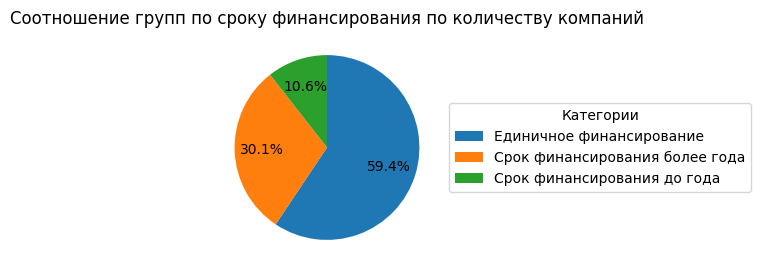

In [66]:
# задаем размер графика
plt.figure(figsize=(7, 3))

data_pie = df['funding_group'].value_counts()

# строим круговую диаграмму
data_pie.plot(
               kind='pie', 
               legend=True,
               autopct='%1.1f%%', # добавляем подписи в процентах
               labels=None,
               pctdistance=0.7, # отображаем проценты снаружи графика
               startangle=90,
               counterclock=False
)

plt.title('Соотношение групп по сроку финансирования по количеству компаний')
plt.ylabel('')
plt.xlabel('')

labels = data_pie.index

plt.legend(
    labels,
    title='Категории',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

plt.show()

Преобдалает единичное финансирование – 59.4%. Длительное финансирование (более года) составляет 30.1%, а финансирование до года наименее распространено – всего 10.6%.

Построим график по объему инвестиций – покажем, какую долю от общего объема привлеченных средств получила каждая группа.

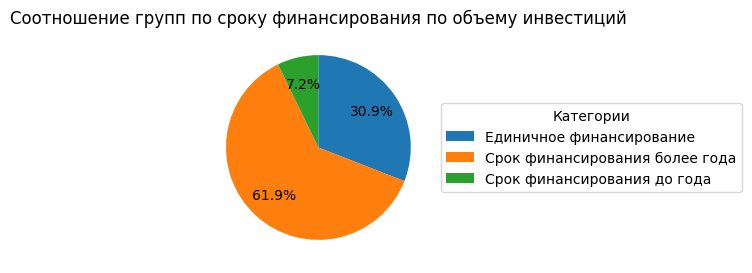

In [67]:
# задаем размер графика
plt.figure(figsize=(7, 3))

data_pie = df.groupby('funding_group')['funding_total_usd'].sum()

# строим круговую диаграмму
data_pie.plot(
               kind='pie', 
               legend=True,
               autopct='%1.1f%%', # добавляем подписи в процентах
               labels=None,
               pctdistance=0.7, # отображаем проценты снаружи графика
               startangle=90,
               counterclock=False
)

plt.title('Соотношение групп по сроку финансирования по объему инвестиций')
plt.ylabel('')
plt.xlabel('')

labels = data_pie.index

plt.legend(
    labels,
    title='Категории',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

plt.show()

Наибольшую долю по объему привлеченных инвестиций занимает группа со сроком финансирования более года – 61.9%. Единичное финансирование составляет 30.9% всего обхема инвестиций, а финансирование до года – всего 7.2%.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

---

In [68]:
# напишем функцию для классификации по сегментам рынка

counts = df['market'].value_counts()

def market_classify(counts):
    if counts < 35:
        return 'niche'
    elif counts <= 120:
        return 'mid'
    elif counts > 120:
        return 'mass'

df['market_group'] = df['market'].map(counts).apply(market_classify)

Рассчитаем, сколько компаний попало в каждый сегмент:

In [69]:
df['market_group'].value_counts()

market_group
mass     33732
mid       3840
niche      830
Name: count, dtype: int64

В массовый сегмент вошло 33732 компании, в средний – 3840, а в нишевый – 830. 

Построим график распределения количества компаний в сегментах:

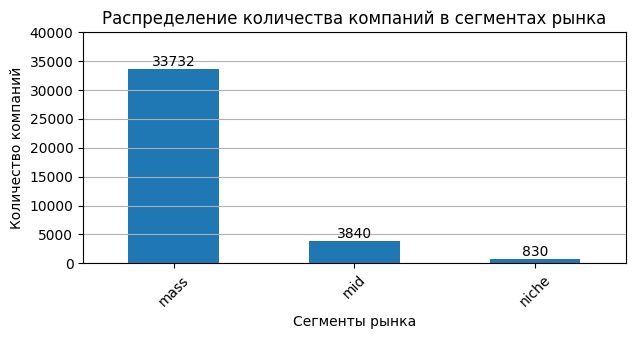

In [70]:
# задаtм размер графика
plt.figure(figsize=(7, 3))

# строим столбчатую диаграмму
ax = df['market_group'].value_counts().plot(
               kind='bar', 
               rot=45,
               legend=False
)

# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.0f}' for bar in bars])
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )

plt.ylim(0, 40000)   # диапазон оси Y

plt.title('Распределение количества компаний в сегментах рынка')
plt.xlabel('Сегменты рынка')
plt.ylabel('Количество компаний')
plt.grid(axis='y')

plt.show()

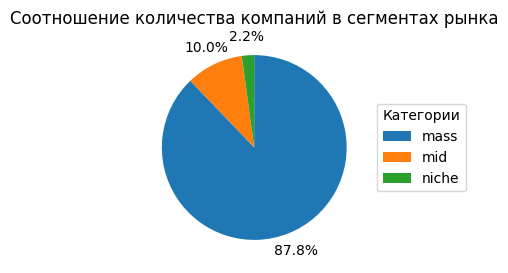

In [71]:
# задаем размер графика
plt.figure(figsize=(7, 3))

data_pie = df['market_group'].value_counts()

# строим круговую диаграмму
data_pie.plot(
               kind='pie', 
               legend=True,
               autopct='%1.1f%%', # добавляем подписи в процентах
               labels=None,
               pctdistance=1.2, # отображаем проценты снаружи графика
               startangle=90,
               counterclock=False
)

plt.title('Соотношение количества компаний в сегментах рынка')
plt.ylabel('')
plt.xlabel('')

labels = data_pie.index

plt.legend(
    labels,
    title='Категории',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

plt.show()

Среди компаний с известной классификацией по рынку (у которых заполнен столбец `market`) преобладает массовый сегмент (т.е. сегмент рынка, по которому более 120 компаний) – 33732 компании или 87.8%. У среднего и нишевого сегментов по 10.0% и 2.2% (или 3840 и 830 компаний). Компаний с неустановленным сегментом 2503 штуки.

---
Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования будем выполнять с учетом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не будем — они объединяются в два общих сегмента.

---

In [72]:
# сохраним изначальный столбец market в дополнительном столбце
df['market_old'] = df['market']

In [73]:
df.loc[df['market_group'] == 'mid', 'market'] = 'mid'
df.loc[df['market_group'] == 'niche', 'market'] = 'niche'

In [74]:
df['market'].sort_values().unique()

array(['Advertising', 'Analytics', 'Apps', 'Automotive', 'Big Data',
       'Biotechnology', 'Clean Technology', 'Cloud Computing',
       'Consulting', 'Curated Web', 'Design', 'E-Commerce', 'Education',
       'Enterprise Software', 'Entertainment', 'Fashion', 'Finance',
       'Games', 'Hardware + Software', 'Health Care',
       'Health and Wellness', 'Hospitality', 'Internet', 'Manufacturing',
       'Marketplaces', 'Medical', 'Messaging', 'Mobile', 'Music',
       'Networking', 'News', 'Nonprofits', 'Photography',
       'Public Relations', 'Real Estate', 'SaaS', 'Search', 'Security',
       'Semiconductors', 'Social Media', 'Social Network Media',
       'Software', 'Sports', 'Startups', 'Technology', 'Travel', 'Video',
       'Web Hosting', 'mid', 'niche', nan], dtype=object)

Построим график распределения количества компаний в сегментах нишевые и средние:

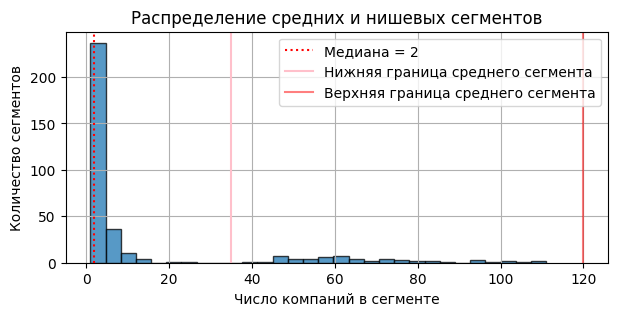

In [75]:
market_counts = df[df['market'].isin(['mid', 'niche'])]['market_old'].value_counts()

median = market_counts.median()

plt.figure(figsize=(7, 3))

market_counts.hist(
    bins=30,
    alpha=0.75, 
    edgecolor='black'
)

plt.axvline(median, color='red', linestyle=':', label=f'Медиана = {median:.0f}')
plt.axvline(35, color='pink', linestyle='-', label= 'Нижняя граница среднего сегмента')
plt.axvline(120, color='red', alpha=0.5, linestyle='-', label='Верхняя граница среднего сегмента')

plt.title('Распределение средних и нишевых сегментов')
plt.xlabel('Число компаний в сегменте')
plt.ylabel('Количество сегментов')

plt.legend()
plt.show()

По графику видно, что бОльшая концентрация различных подсегментов наблюдается в нишевом сегменте. В среднем сегменте значительно меньше подсегментов, при этом большее число компаний в каждом из подсегменов.
Медианное число компаний в одном сегменте – 2 штуки (большое влияние на это значение оказал нишевый сегмент).

**Итоги:**

Разделили все компании на три группы по срокам финансирования: единичное финансирование, срок финансирования до года, срок финансирования более года.

Исследовали соотношение их групп:

- По сроку финансирования: Преобдалает единичное финансирование – 59.4%. Длительное финансирование (более года) составляет 30.1%, а финансирование до года наименее распространено – всего 10.6%.

- По объему привлеченных инвестиций: Наибольшую долю занимает группа со сроком финансирования более года – 61.9%. Единичное финансирование составляет 30.9% всего объема инвестиций, а финансирование до года – всего 7.2%.


Выделили массовые, средние и нишевые сегменты рынка по столбцу `market`, определили популярность каждого из сегментов – в массовый сегмент вошло 33732 компании, в средний – 3840, а в нишевый – 830. Непопулярные сегменты из категорий средние и нишевые объединили в категориях `mid` и `niche`.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

---

Посмотрим на описательные статистики данных в столбце `funding_total_usd`:

In [76]:
df['funding_total_usd'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

count    4.090500e+04
mean     1.591290e+07
std      1.686829e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
95%      6.000000e+07
99%      2.000000e+08
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Среднее значение более чем в 10 раз превышает медиану, а максимальное значение аномально высокое (более чем в 100 раз больше 99% перцентиля). Это говорит о большом количестве выбросов в данных, которые искажают распределение.

Построим диаграмму размаха значений в столбце `funding_total_usd`:

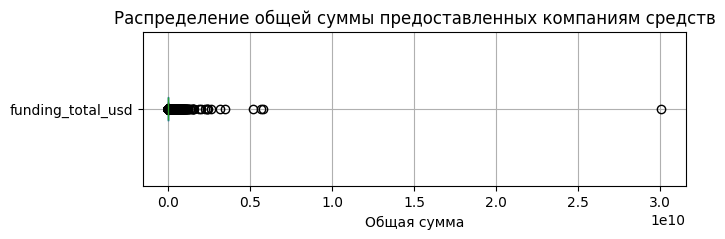

In [77]:
# строим диаграмму размаха значений

plt.figure(figsize=(7, 2))

df.boxplot(column='funding_total_usd', vert=False)

plt.title('Распределение общей суммы предоставленных компаниям средств')
plt.xlabel('Общая сумма')

plt.show()

Действительно, в данных большое число выбросов, есть даже одно аномально высокое значение, которое сильно портит картинку. Из-за выбросов не видно, как распределена основная масса данных. Скроем отображение выбросов и построим график размаха без них:

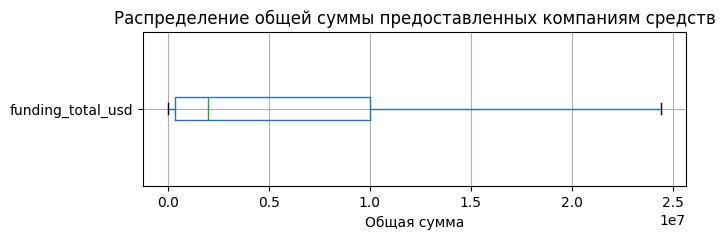

In [78]:
# строим диаграмму размаха значений

plt.figure(figsize=(7, 2))

df.boxplot(column='funding_total_usd', vert=False, showfliers=False) # скрываем отображение выбросов

plt.title('Распределение общей суммы предоставленных компаниям средств')
plt.xlabel('Общая сумма')

plt.show()

Построим гистограмму распределения сумм, при этом отбросим выбросы, ограничив набор данных 95-м перцентилем:

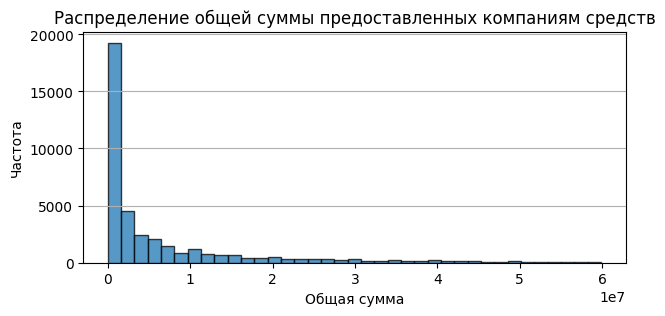

In [79]:
# задаем размер графика
plt.figure(figsize=(7, 3))

# находим 95-й перцентиль
outliers = df['funding_total_usd'].quantile(0.95)

# отбираем данные, оставляя значения меньше найденного порога выбросов
new_df = df.loc[df['funding_total_usd'] < outliers]

# строим гистограмму
new_df['funding_total_usd'].plot(
                kind='hist',
                bins=37, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)

# настраиваем оформление графика
plt.title('Распределение общей суммы предоставленных компаниям средств')
plt.xlabel('Общая сумма')
plt.ylabel('Частота')
plt.grid(axis='y')

plt.show()

По данному графику также видно, что в основном суммы финансирования сосредоточены в диапазоне до 1е+7, то есть до 10 млн долларов (а основная масса до 1,5-2,5 млн долларов).

Посчитаем верхний порог для выбросов:

In [80]:
# вычисляем квартили Q1 и Q3
Q1 = df['funding_total_usd'].quantile(0.25)
Q3 = df['funding_total_usd'].quantile(0.75)

# вычисляем межквартильный размах IQR
IQR = Q3 - Q1

# определяем верхний порог для выбросов
upper_bound = Q3 + 1.5 * IQR
upper_bound

np.float64(24475000.0)

С помощью диаграммы размаха и описательной статистики определим интервал, в котором лежат типичные значения суммы финансирования:

Наблюдаемый минимум и максимум без учета выбросов составляют 0 и 24.475 млн долларов – это границы интервала.
Центральные 50% значений лежат в диапазоне от 0.35 млн долларов (25% процентиль) до 10 млн долларов (75% процентиль). Медиана составляет 2 млн долларов. 
Все суммы выше 25 млн долларов считаются выбросами.

---
Определим компании с аномальным объёмом общего финансирования — используем метод IQR отдельно по каждому сегменту.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

---

Рассчитаем верхние границы для выбросов по каждому сегменту с целью определения доли аномального финансирования компаний.

In [81]:
# вычисляем квартили Q1 и Q3
Q1 = df.groupby('market')['funding_total_usd'].agg(lambda x: x.quantile(0.25))
Q3 = df.groupby('market')['funding_total_usd'].agg(lambda x: x.quantile(0.75))

# вычисляем межквартильный размах IQR
IQR = Q3 - Q1

# определяем верхний порог для выбросов
upper_bound = Q3 + 1.5 * IQR

Определяем, является ли компания аномально профинансированной в своем сегменте рынка (т.е. выбросом):

In [82]:
df['is_outlier_in_segment'] = (df['funding_total_usd'] > df['market'].map(upper_bound))

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [83]:
df.groupby('market')['is_outlier_in_segment'].mean().mul(100).sort_values(ascending=False)

market
Real Estate             17.204301
Entertainment           16.666667
Consulting              16.618911
Search                  16.494845
Cloud Computing         16.447368
Photography             16.176471
SaaS                    16.176471
Technology              15.966387
Video                   15.957447
niche                   15.903614
Travel                  15.454545
Networking              15.384615
Internet                15.352697
Big Data                15.333333
Marketplaces            15.306122
mid                     14.479167
E-Commerce              14.415863
Apps                    14.349776
Automotive              14.193548
Medical                 13.907285
Sports                  13.725490
Social Media            13.559322
News                    13.289037
Education               13.270142
Fashion                 13.201320
Mobile                  13.182594
Hospitality             13.095238
Health and Wellness     12.943872
Messaging               12.881356
Startup

Из 50 сегментов выделим топ-15 с наибольшей долей аномально финансированных компаний:

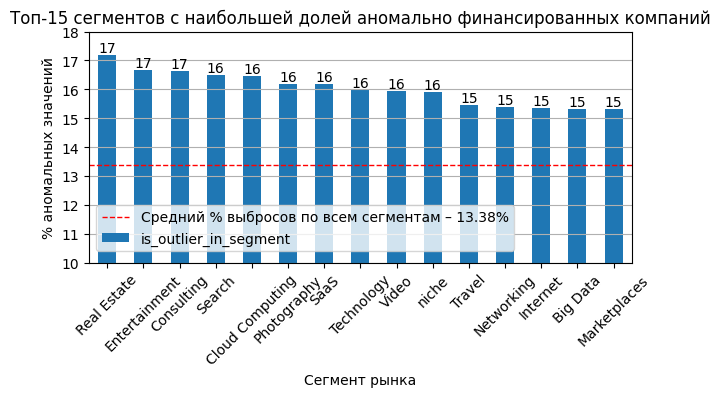

In [84]:
plt.figure(figsize=(7, 3))

data = df.groupby('market')['is_outlier_in_segment'].mean().mul(100).sort_values(ascending=False)

# строим столбчатую диаграмму
ax = data.head(15).plot(
               kind='bar', 
               rot=45
)

plt.title('Топ-15 сегментов с наибольшей долей аномально финансированных компаний')
plt.xlabel('Сегмент рынка')
plt.ylabel('% аномальных значений')
plt.grid(axis='y')


# рассчитаем среднее значение по всем данным
mean = data.mean()

# добавим на график линию с общим средним 
plt.axhline(mean, 
            color='red',
            linestyle='--', 
            linewidth=1,
            label=f'Средний % выбросов по всем сегментам – {round(mean,2)}%')

plt.ylim(10, 18) # сократим диапазон оси Y для наглядности 


# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.1f}' for bar in bars], fontsize=9)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )

plt.legend(
    loc='center left',
    bbox_to_anchor=(0, 0.15) # перенос легенды
)

plt.show()

Максимальны процент выбросов наблюдается в сегменте Real Estate – 17.20%.
Минимальный процент выбросов среди всех сегментов – в сегменте Semiconductors – 7.02%.

В топ-15 по наибольшей доле аномальных сумм финансирования вошли такие сегменты как: 
Real Estate (17.2%), Entertainment, Consulting, Search, Cloud Computing, Photography, SaaS, Technology, Video, niche, Travel, Networking, Internet, Big Data, Marketplaces (15.3%).


P.S.: При анализе инвестиционного климата и темпов роста по рынкам стоит учитывать, что ряд сегментов из топа по выбросам не всегда подходит для расчёта "средней температуры по больнице". Компании с аномально большими инвестициями могут искусственно увеличивать значения суммарного финансирования и искажать выводы о реальном положении дел на отраслевом уровне.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Далее на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определенных компаниях, которые должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

---

In [85]:
df[df['founded_month'] > '2014-01']['founded_month'].unique()

array(['2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07',
       '2014-08', '2014-09', '2014-10', '2014-11', '2014-12'],
      dtype=object)

In [86]:
df[df['founded_at'] > '2014-01-01']['founded_at'].unique()

<DatetimeArray>
['2014-01-02 00:00:00', '2014-01-03 00:00:00', '2014-01-04 00:00:00', '2014-01-06 00:00:00', '2014-01-07 00:00:00', '2014-01-08 00:00:00', '2014-01-09 00:00:00', '2014-01-10 00:00:00', '2014-01-11 00:00:00', '2014-01-12 00:00:00',
 ...
 '2014-10-19 00:00:00', '2014-10-21 00:00:00', '2014-10-22 00:00:00', '2014-10-26 00:00:00', '2014-10-30 00:00:00', '2014-11-05 00:00:00', '2014-11-19 00:00:00', '2014-11-26 00:00:00', '2014-12-01 00:00:00', '2014-12-13 00:00:00']
Length: 203, dtype: datetime64[ns]

In [87]:
df[df['last_funding_at'] > '2014-01-01']['last_funding_at'].unique()

<DatetimeArray>
['2014-01-06 00:00:00', '2014-05-15 00:00:00', '2014-11-03 00:00:00', '2014-01-14 00:00:00', '2014-10-23 00:00:00', '2014-01-12 00:00:00', '2014-09-30 00:00:00', '2014-05-05 00:00:00', '2014-02-06 00:00:00', '2014-07-30 00:00:00',
 ...
 '2014-07-13 00:00:00', '2014-03-22 00:00:00', '2014-12-24 00:00:00', '2014-04-19 00:00:00', '2014-04-26 00:00:00', '2014-07-12 00:00:00', '2014-11-16 00:00:00', '2014-11-22 00:00:00', '2014-11-23 00:00:00', '2014-12-31 00:00:00']
Length: 334, dtype: datetime64[ns]

Да, можно сказать, что нам предоставлены полные данные за 2014 год, поскольку последняя встречающаяся дата финансирования last_funding_at – '2014-12-31 00:00:00', а последняя дата основания компании founded_at – '2014-12-13 00:00:00', т.е. присутствуют полные данные до 31 декабря 2014 года.

Исключим из датасета компании, которые получили аномальное финансирование по каждому сегменту.

In [88]:
num_dropped = df['is_outlier_in_segment'].sum()
perc_dropped = round(df['is_outlier_in_segment'].sum() / df.shape[0] * 100, 2)

print(f'Исключаем компании с аномальным финансированием – это {num_dropped} строк или {perc_dropped}% данных.')

Исключаем компании с аномальным финансированием – это 4871 строк или 11.91% данных.


In [89]:
df[df['funding_total_usd'] > 25000000].shape[0]

5038

Если бы мы удаляли выбросы по всему столбцу `funding_total_usd` по условию, что выбросами считались бы все значения выше 25 млн долларов, то мы удалили бы больше данных, чем по сегментам (5038 вместо 4871).

In [90]:
df = df[df['is_outlier_in_segment'] == False].reset_index(drop=True)

In [91]:
df.tail()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_total_usd_true,funding_group,market_group,market_old,is_outlier_in_segment
36029,riversilica,http://riversilica.com,NaN,NaN,1500000.0,operating,IND,NaN,Bangalore,Bangalore,1.0,NaN,NaT,NaN,NaN,NaN,2014-12-01,2014-12-01,2014-12-01,0.0,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1500000.0,Единичное финансирование,None,NaN,False
36030,southgobi resources,http://southgobi.com,|Mining Technologies|,niche,9000000.0,operating,CAN,BC,Vancouver,Vancouver,1.0,NaN,NaT,NaN,NaN,NaN,2014-12-01,2014-12-01,2014-12-01,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9000000.0,Единичное финансирование,niche,Mining Technologies,False
36031,digibyte,http://digibyte.co,NaN,NaN,250000.0,operating,USA,CA,Los Angeles,Santa Monica,1.0,NaN,NaT,NaN,NaN,NaN,2014-12-02,2014-12-02,2014-12-02,0.0,250000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250000.0,Единичное финансирование,None,NaN,False
36032,xeltis,http://xeltis.com,NaN,NaN,34000000.0,operating,CHE,NaN,Zurich,Zürich,1.0,NaN,NaT,NaN,NaN,NaN,2014-12-02,2014-12-02,2014-12-02,0.0,34000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34000000.0,0.0,0.0,0.0,0.0,0.0,0.0,68000000.0,Единичное финансирование,None,NaN,False
36033,logovers,http://www.logovers.com/,|Incubators|Designers|Entrepreneur|Startups|,Startups,11500.0,operating,MEX,NaN,MEX - Other,Hermosillo,1.0,NaN,NaT,NaN,NaN,NaN,2014-12-31,2014-12-31,2014-12-31,11500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11500.0,Единичное финансирование,mass,Startups,False


Аномально финансированные компании исключили. Теперь на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только о таких компаниях, которые получили финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [92]:
df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].sum()

mid_funding_at
1921        1.0
1960        2.0
1979        1.0
1982        3.0
1983        1.0
1984        2.0
1985        3.0
1987        2.0
1989        1.0
1990        1.0
1992        5.0
1993        1.0
1994        4.0
1995        9.0
1996        8.0
1997        5.0
1998       15.0
1999       47.0
2000      122.0
2001       84.0
2002      107.0
2003      128.0
2004      189.0
2005      958.0
2006     1881.0
2007     2849.0
2008     3686.0
2009     4669.0
2010     6199.0
2011     7617.0
2012     9752.0
2013    12945.0
2014     7244.0
Name: funding_rounds, dtype: float64

In [93]:
# tramsform как оконная функция подставит расчеты в столбец, и мы отберем нужные строки по фильтру
df = df[df.groupby(df['mid_funding_at'].dt.year)['funding_rounds'].transform('sum') >= 50].reset_index(drop=True)

In [94]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h,funding_total_usd_true,funding_group,market_group,market_old,is_outlier_in_segment
0,university of new brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000000.0,Единичное финансирование,None,NaN,False
1,dupont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9000000.0,Единичное финансирование,mid,Business Services,False
2,university of michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7700000.0,Срок финансирования до года,mass,Education,False
3,case western reserve university,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,Единичное финансирование,mass,Education,False
4,xavier university,http://www.xavier.edu/,NaN,NaN,19000000.0,operating,USA,OH,Cincinnati,Cincinnati,1.0,NaN,1831-01-01,NaN,NaN,1831.0,2014-10-23,2014-10-23,2014-10-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,Единичное финансирование,None,NaN,False


In [95]:
df['mid_funding_at'].dt.year.sort_values().unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014], dtype=int32)

Фильтрация проведена успешно – в датафреме остались данные только с 2000 по 2014 год, когда было зафиксировано 50 и более кругов финансирования.

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объемами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объемом предоставленных сумм.

---

In [96]:
funding_info = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

In [97]:
# отобразим суммы по столбцам в млрд долларов
funding_types_sum = df[funding_info].sum() / 1000000000
funding_types_sum

seed                      9.494103
venture                 133.987229
equity_crowdfunding       0.262961
undisclosed               2.924353
convertible_note          0.567145
debt_financing           14.305183
angel                     2.501264
grant                     2.168263
private_equity            9.262413
post_ipo_equity           5.099300
post_ipo_debt             4.286718
secondary_market          0.124086
product_crowdfunding      0.193310
dtype: float64

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег.

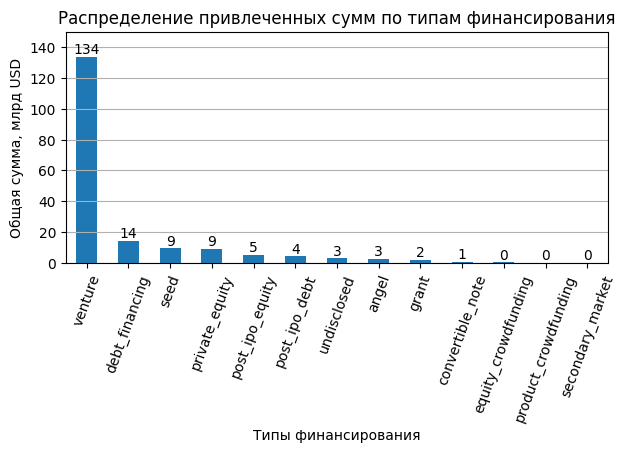

In [98]:
plt.figure(figsize=(7, 3))

# строим столбчатую диаграмму
ax = funding_types_sum.sort_values(ascending=False).plot(
               kind='bar', 
               rot=70,
               legend=False
)

plt.title('Распределение привлеченных сумм по типам финансирования')
plt.xlabel('Типы финансирования')
plt.ylabel('Общая сумма, млрд USD')
plt.grid(axis='y')

# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.1f}' for bar in bars], fontsize=9)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
plt.ylim(0, 150) # диапазон оси Y 

plt.show()

Больше всего средств было привлечено с помощью венчурных инфестиций (venture) – 134 млрд долларов. Этот тип финансирования лидирует с сильным отрывом, по остальным типам было привлечено почти в 10 и более раз меньше средств. Второе место в топе занимает долговое финансирование (debt_financing) – привлечено в сумме 14.3 млрд долларов. На третьем месте инвестиции на посевной стадии (seed) – 9.5 млрд, близкая сумма по инвестициям в виде прямых (частных) вложений (private_equity) – 9.3 млрд. Последнее место по размеру привлеченных сумм занимают сделки на вторичном рынке (secondary_market) – 0.1 млрд долларов.

Построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

In [99]:
funding_types_count = (df[funding_info] != 0).sum()
funding_types_count

seed                    13387
venture                 19060
equity_crowdfunding       516
undisclosed               834
convertible_note          522
debt_financing           3312
angel                    2938
grant                    1020
private_equity            680
post_ipo_equity           177
post_ipo_debt              29
secondary_market            8
product_crowdfunding      205
dtype: int64

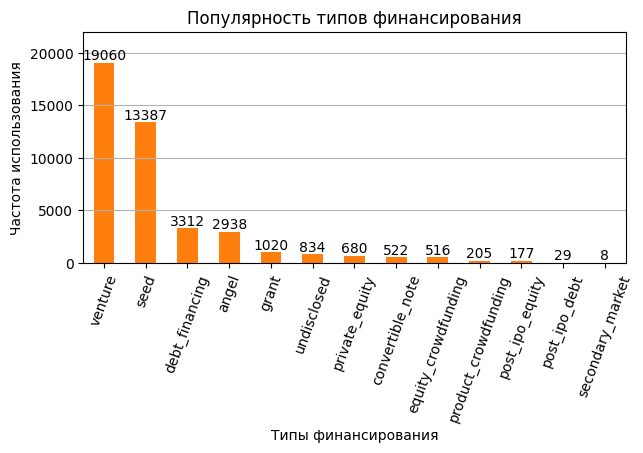

In [100]:
plt.figure(figsize=(7, 3))

# строим столбчатую диаграмму
ax = funding_types_count.sort_values(ascending=False).plot(
               kind='bar', 
               rot=70,
               legend=False,
               color='#ff7f0e'
)

plt.title('Популярность типов финансирования')
plt.xlabel('Типы финансирования')
plt.ylabel('Частота использования')
plt.grid(axis='y')

# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.0f}' for bar in bars], fontsize=9)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
plt.ylim(0, 22000) # диапазон оси Y 

plt.show()

Чаще всего компаниями используется венчурный тип финансирования (venture) – он встречается 19060 раз, на втором месте инвестиции на посевной стадии (seed) – 13387 раз. Остальные типы пользуются значительно меньшей популярностью – около 3000 долговое финансирование и инвестиции от бизнес-ангелов, а остальные типы встречаются менее 1000 раз. Меньше всего популярнв сделки на вторичном рынке (secondary_market) – всего 8 раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [101]:
# объединим расчеты в один датафрейм
funding_types_sum_df = pd.DataFrame(funding_types_sum)
funding_types_sum_df.columns = ['sum']

funding_types_count_df = pd.DataFrame(funding_types_count)
funding_types_count_df.columns = ['count']

funding_agg = funding_types_sum_df.join(funding_types_count_df)
# funding_agg

In [102]:
# нормируем столбцы
funding_agg_perc = funding_agg.copy()
funding_agg_perc[['sum', 'count']] = funding_agg_perc[['sum', 'count']].apply(lambda x: x / x.sum() * 100)

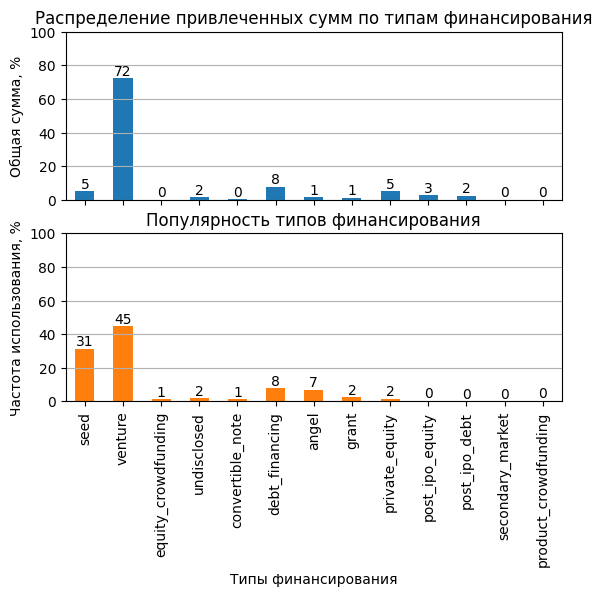

In [103]:
ax = funding_agg_perc.plot(kind='bar',
                   subplots=True,
                   sharex=True,
                   sharey=False,
                   legend=False,
                   title=['Распределение привлеченных сумм по типам финансирования', 'Популярность типов финансирования'])

# устанавливаем подпись для оси Y каждого из подграфиков
ax[0].set_ylabel('Общая сумма, %')
ax[1].set_ylabel('Частота использования, %')

# включаем сетку для каждого из подграфиков
ax[0].grid(axis='y')
ax[1].grid(axis='y')

# добавим подписи значений на график
bars_0 = ax[0].containers[0]
# ax[0].bar_label(bars_0, labels=[f'{bar.get_height():.1f}%' for bar in bars_0], fontsize=9)
for bar in bars_0:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
bars_1 = ax[1].containers[0]
# ax[1].bar_label(bars_1, labels=[f'{bar.get_height():.1f}%' for bar in bars_1], fontsize=9)
for bar in bars_1:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
# диапазон оси Y
ax[0].set_ylim(0, 100)  
ax[1].set_ylim(0, 100)

# подписываем ось X
plt.xlabel('Типы финансирования')
plt.show()

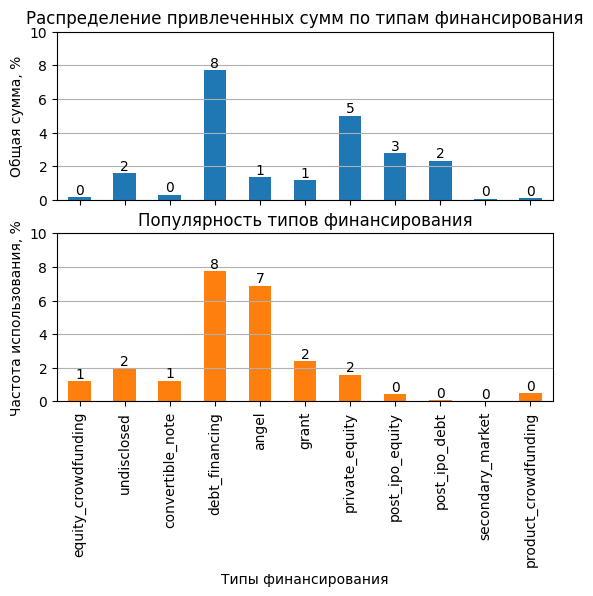

In [104]:
# скроем с графиков столбцы venture и seed, чтобы ближе посмотреть на остальные типы
funding_agg_perc_new = funding_agg_perc.drop(index=['venture', 'seed'])

ax = funding_agg_perc_new.plot(kind='bar',
                   subplots=True,
                   sharex=True,
                   sharey=False,
                   legend=False,
                   title=['Распределение привлеченных сумм по типам финансирования', 'Популярность типов финансирования'])

# устанавливаем подпись для оси Y каждого из подграфиков
ax[0].set_ylabel('Общая сумма, %')
ax[1].set_ylabel('Частота использования, %')

# включаем сетку для каждого из подграфиков
ax[0].grid(axis='y')
ax[1].grid(axis='y')

# добавим подписи значений на график
bars_0 = ax[0].containers[0]
# ax[0].bar_label(bars_0, labels=[f'{bar.get_height():.1f}%' for bar in bars_0], fontsize=9)
for bar in bars_0:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
bars_1 = ax[1].containers[0]
# ax[1].bar_label(bars_1, labels=[f'{bar.get_height():.1f}%' for bar in bars_1], fontsize=9)
for bar in bars_1:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )

# диапазон оси Y
ax[0].set_ylim(0, 10)  
ax[1].set_ylim(0, 10)

# подписываем ось X
plt.xlabel('Типы финансирования')
plt.show()

In [105]:
(funding_agg_perc['sum'] - funding_agg_perc['count']).sort_values(ascending=False)

venture                 27.707014
private_equity           3.408989
post_ipo_equity          2.339117
post_ipo_debt            2.247004
secondary_market         0.048269
debt_financing          -0.033452
undisclosed             -0.374485
product_crowdfunding    -0.375836
convertible_note        -0.916553
equity_crowdfunding     -1.066765
grant                   -1.218512
angel                   -5.531749
seed                   -26.233040
dtype: float64

Доля по частоте превышает долю по суммам:

seed,
angel,
grant,
equity_crowdfunding,
convertible_note,
product_crowdfunding,
undisclosed,
debt_financing

Доля по суммам превышает долю по частоте:

venture,
private_equity,
post_ipo_equity,
post_ipo_debt,
secondary_market

Столбец venture самый популярный по частоте и лидирующий по максимальным привлеченным суммам.

Часто используемые типы финансирования, но c небольшими объемами предоставленных сумм:
seed.

Редко встречающиеся типы, но со значительным объемом предоставленных сумм:
сложно выделить типы, которые бы подошли под это условие.

---
Построим график суммарных объемов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

---

In [106]:
df_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [107]:
df_returns.sum()

seed                     2382.24
venture                 40578.62
equity_crowdfunding         3.83
undisclosed               730.88
convertible_note           34.79
debt_financing           4734.85
angel                    1509.23
grant                       0.00
private_equity           3587.33
post_ipo_equity          1104.96
post_ipo_debt              91.03
secondary_market            5.20
product_crowdfunding        1.86
dtype: float64

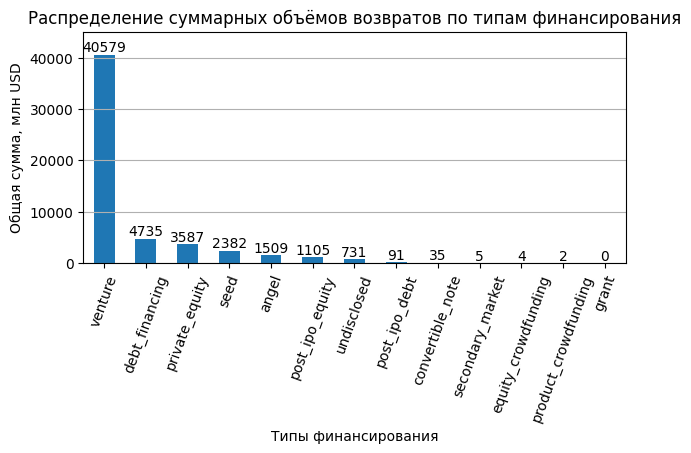

In [108]:
plt.figure(figsize=(7, 3))

# строим столбчатую диаграмму
ax = df_returns.sum().sort_values(ascending=False).plot(
               kind='bar', 
               rot=70,
               legend=False
)

plt.title('Распределение суммарных объёмов возвратов по типам финансирования')
plt.xlabel('Типы финансирования')
plt.ylabel('Общая сумма, млн USD')
plt.grid(axis='y')

# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.0f}' for bar in bars], fontsize=9)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
plt.ylim(0, 45000) # диапазон оси Y 

plt.show()

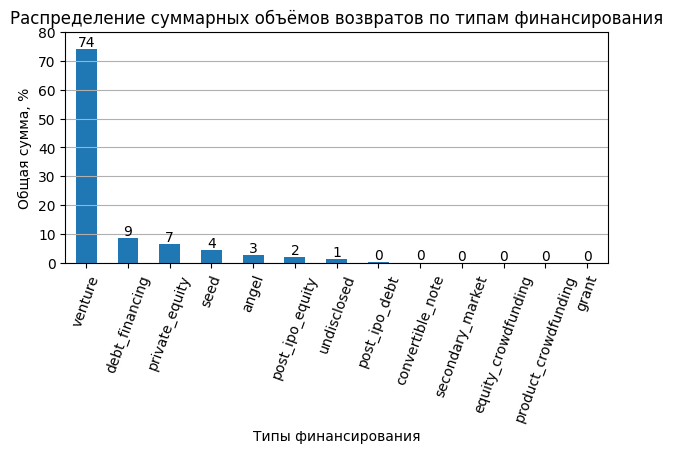

In [109]:
plt.figure(figsize=(7, 3))

# строим столбчатую диаграмму
ax = (df_returns.sum() / df_returns.sum().sum() * 100).sort_values(ascending=False).plot(
               kind='bar', 
               rot=70,
               legend=False
)

plt.title('Распределение суммарных объёмов возвратов по типам финансирования')
plt.xlabel('Типы финансирования')
plt.ylabel('Общая сумма, %')
plt.grid(axis='y')

# добавим подписи значений на график
bars = ax.containers[0]
# ax.bar_label(bars, labels=[f'{bar.get_height():.1f}%' for bar in bars], fontsize=9)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )
    
plt.ylim(0, 80) # диапазон оси Y 

plt.show()

По возвратам также лидирует venture – 40.6 млрд долларов (74.1%). Остальные типы сильно отстают: debt_financing – 4.7 млрд (8.6%), private_equity – 3.6 млрд (6.6%), seed – 2.4 млрд (4.3%). Минимальный возврат по типу grant – 0.

**Итоги:**

С помощью диаграммы размаха и описательной статистики определили интервал, в котором лежат типичные значения суммы финансирования:

- Наблюдаемый минимум и максимум без учета выбросов составляют 0 и 24.475 млн долларов – это границы интервала. Центральные 50% значений лежат в диапазоне от 0.35 млн долларов (25% процентиль) до 10 млн долларов (75% процентиль). Медиана составляет 2 млн долларов. Все суммы выше 25 млн долларов считаются выбросами.


Определили сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и рассмотрели топ таких сегментов:

- Максимальны процент выбросов наблюдается в сегменте Real Estate – 17.20%. Минимальный процент выбросов среди всех сегментов – в сегменте Semiconductors – 7.02%.

- В топ-15 по наибольшей доле аномальных сумм финансирования вошли такие сегменты как: Real Estate (17.2%), Entertainment, Consulting, Search, Cloud Computing, Photography, SaaS, Technology, Video, niche, Travel, Networking, Internet, Big Data, Marketplaces (15.3%).

- Исключили из датасета компании, которые получили аномальное финансирование. Оставили в датасете данные только о тех компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.


Провели анализ типов финансирования по объему и популярности:

- Построили график, который показывает, какие типы финансирования в сумме привлекли больше всего денег.

Больше всего средств было привлечено с помощью венчурных инфестиций (venture) – 134 млрд долларов. Этот тип финансирования лидирует с сильным отрывом, по остальным типам было привлечено почти в 10 и более раз меньше средств. Второе место в топе занимает долговое финансирование (debt_financing) – привлечено в сумме 14.3 млрд долларов. На третьем месте инвестиции на посевной стадии (seed) – 9.5 млрд, близкая сумма по инвестициям в виде прямых (частных) вложений (private_equity) – 9.3 млрд. Последнее место по размеру привлеченных сумм занимают сделки на вторичном рынке (secondary_market) – 0.1 млрд долларов.


- Построили график, который показывает популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Чаще всего компаниями используется венчурный тип финансирования (venture) – он встречается 19060 раз, на втором месте инвестиции на посевной стадии (seed) – 13387 раз. Остальные типы пользуются значительно меньшей популярностью – около 3000 долговое финансирование и инвестиции от бизнес-ангелов, а остальные типы встречаются менее 1000 раз. Меньше всего популярнв сделки на вторичном рынке (secondary_market) – всего 8 раз.


- Сравнили графики и выделили часто используемые типы финансирования, которые при этом характеризуются небольшими объемами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объемом предоставленных сумм.

Тип venture – самый популярный по частоте и лидирующий по максимальным привлеченным суммам.
Тип seed – часто используемый, но c небольшими объемами предоставленных сумм.
Редко встречающиеся типы, но со значительным объемом предоставленных сумм однозначно выделить сложно.


- Построили график суммарных объемов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

По возвратам также лидирует venture – 40.6 млрд долларов (74.1%). Остальные типы сильно отстают: debt_financing – 4.7 млрд (8.6%), private_equity – 3.6 млрд (6.6%), seed – 2.4 млрд (4.3%). Минимальный возврат по типу grant – 0.


Наибольший суммарный объем возвратов за весь период приходится на венчурное финансирование. Остальные типы финансирования демонстрируют существенно меньший вклад в общий объем возвратов, что указывает на концентрацию доходности в венчурных инвестициях и более поздних стадиях развития компаний.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объем одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).


На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

---

In [110]:
df['avg_roung_sum'] = df['funding_total_usd'] / df['funding_rounds']

In [111]:
dynamics = df.groupby(df['mid_funding_at'].dt.year).agg({'avg_roung_sum': 'median', 'funding_rounds': 'sum'})
dynamics['avg_roung_sum'] = round(dynamics['avg_roung_sum'] / 1000, 2)
# dynamics = dynamics.drop(columns='avg_roung_sum')
dynamics = dynamics.reindex(columns=['avg_roung_sum', 'funding_rounds'])
dynamics

,avg_roung_sum,funding_rounds
mid_funding_at,,
2000,2365.23,122.0
2001,2368.58,84.0
2002,3750.00,107.0
2003,1505.00,128.0
2004,3066.67,189.0
2005,4500.00,958.0
2006,3945.34,1881.0
2007,2893.27,2849.0
2008,2225.00,3686.0


<Figure size 700x300 with 0 Axes>

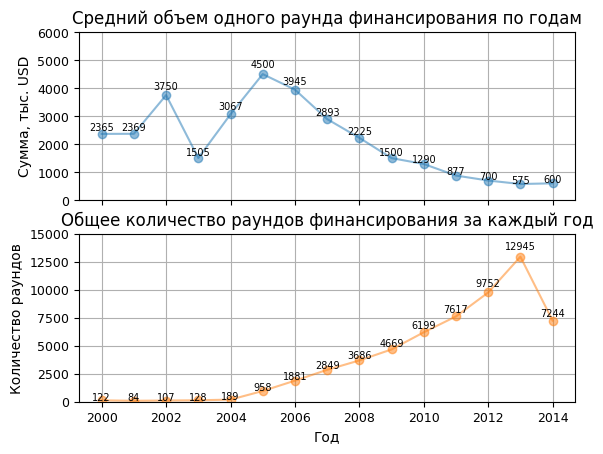

In [112]:
plt.figure(figsize=(7, 3))
ax = dynamics.plot(kind='line',
                   subplots=True,
                   sharex=True,
                   sharey=False,
                   legend=False,
                   marker='o',
                   alpha=0.5,
                   title=['Средний объем одного раунда финансирования по годам', 'Общее количество раундов финансирования за каждый год'])

# устанавливаем подпись для оси Y каждого из подграфиков
ax[0].set_ylabel('Cумма, тыс. USD')
ax[1].set_ylabel('Количество раундов')

# включаем сетку для каждого из подграфиков
ax[0].grid(which='both')
ax[1].grid(which='both')

# подписываем ось X
plt.xlabel('Год')

# диапазон оси Y
ax[0].set_ylim(0, 6000)  
ax[1].set_ylim(0, 15000)

# добавляем подписи значений
for i, axis in enumerate(ax):
    for line in axis.get_lines(): # для каждой линии на подграфике
        x_data = line.get_xdata() # значения по X
        y_data = line.get_ydata() # значения по Y
        for x, y in zip(x_data, y_data):
            axis.text(x, y*1.05, f'{y:.0f}', ha='center', fontsize=7)  # подпись чуть выше точки

plt.xticks(fontsize=9) 

ax[0].tick_params(axis='y', labelsize=9) 
ax[1].tick_params(axis='y', labelsize=9) 

plt.show()

- В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

Типичный объем собранных за один раунд средств был максимальным в 2005 году и составлял 4.5 млн долларов.

- Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

Пиковая активность по количствую раундов финансирования за год пришлась на 2013 год – было проведено почти 13 тысяч раундов. В 2014 году общее количество раундов финансирования резко сократилось почти в 2 раза до 7.2 тысяч и опустилась даже ниже уровня 2011 года (хотя до этого все время был рост от года к году). При этом средний объем привлеченных средств в рамках одного раунда немного увеличился в сравнении с 2013 годом и развернул нисходящую тенденцию, длящуюся с 2005 года.


В последние годы (на момент 2014 года) наблюдается бурный рост числа инвестиционных сделок на рынке стартапов, но средний размер одной инвестиции (по медиане) значительно снизился по сравнению с предыдущими годами. Это может свидетельствовать о насыщении рынка, ужесточении конкуренции и популяризации альтернативных/мелких форм финансирования.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой будет указываться суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из нее только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у нас достаточно данных. Будем рассматривать только массовые сегменты, а средние и нишевые исключим.

На основе графика сделаем вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

---

In [113]:
df['funding_year'] = df['mid_funding_at'].dt.year

pivot = df.pivot_table(
    index='market',
    columns='funding_year',
    values='funding_total_usd',
    aggfunc='sum'
)

pivot

funding_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Advertising,14470000.0,8778321.0,24500000.0,10500000.0,6000000.0,127196022.0,2.992995e+08,5.567043e+08,6.226735e+08,5.634460e+08,6.316179e+08,4.107307e+08,5.211370e+08,5.249151e+08,2.077923e+08
Analytics,14822803.0,NaN,7500000.0,3840000.0,3000000.0,79014044.0,1.397013e+08,9.882900e+07,2.080778e+08,1.409493e+08,2.537399e+08,4.433334e+08,5.392143e+08,6.228214e+08,1.514616e+08
Apps,NaN,NaN,NaN,NaN,NaN,NaN,1.310600e+06,NaN,4.300000e+06,7.219000e+06,6.123779e+06,1.837407e+07,3.260112e+07,2.886862e+07,6.623773e+07
Automotive,NaN,NaN,NaN,4530000.0,NaN,22500000.0,1.266000e+07,3.771260e+07,5.947864e+07,2.080031e+07,1.769692e+07,7.645216e+07,3.555768e+07,1.175725e+08,6.903416e+07
Big Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.780000e+06,2.452515e+06,5.973750e+05,3.923330e+07,6.036916e+07,8.641334e+07,7.869892e+07,7.923260e+07
Biotechnology,NaN,NaN,NaN,85531178.0,97184859.0,480063583.0,9.035005e+08,1.704078e+09,1.716033e+09,3.915901e+09,4.894500e+09,4.967552e+09,4.931139e+09,5.694270e+09,2.509639e+09
Clean Technology,NaN,NaN,34390435.0,50352939.0,50427954.0,19420000.0,1.314739e+08,7.497112e+08,3.165808e+09,1.963503e+09,1.604429e+09,1.545603e+09,9.580112e+08,1.203061e+09,6.886868e+08
Cloud Computing,11500000.0,NaN,NaN,NaN,NaN,NaN,9.951809e+06,2.035434e+07,4.437500e+07,5.222372e+07,8.525538e+06,7.315140e+07,7.442158e+07,8.484678e+07,7.344086e+07
Consulting,4500000.0,NaN,NaN,NaN,NaN,44862000.0,2.396555e+07,7.034634e+07,1.906108e+07,6.271516e+07,8.126488e+07,4.341340e+07,6.592276e+07,9.332132e+07,5.429802e+07


In [114]:
growing_segments = pivot[pivot[2014] > pivot[2013]]
# growing_segments

In [115]:
# оставляем только массовые сегменты
growing_segments_mass = growing_segments.drop(index=['mid', 'niche'])
# growing_segments_mass

In [116]:
growing_segments_mass_t = growing_segments_mass.T
growing_segments_mass_t

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology
funding_year,,,,,,,,,,
2000,NaN,NaN,NaN,10000000.0,56659310.0,24000000.0,2500000.0,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,2368582.0,NaN,NaN,NaN,NaN,22160000.0
2002,NaN,NaN,NaN,1100000.0,NaN,NaN,5275000.0,2000000.0,NaN,11000000.0
2003,NaN,NaN,NaN,NaN,4269608.0,NaN,6292200.0,NaN,NaN,NaN
2004,NaN,NaN,NaN,10500000.0,3000000.0,NaN,NaN,NaN,NaN,1750000.0
2005,NaN,NaN,9300000.0,1775000.0,61770000.0,11090000.0,250000.0,5240000.0,NaN,50728425.0
2006,1310600.0,NaN,707000.0,5000.0,163957751.0,20250000.0,2080000.0,4791121.0,NaN,22791000.0
2007,NaN,7780000.0,10800000.0,4495379.0,147726051.0,2100000.0,33220000.0,14652595.0,NaN,180190209.0
2008,4300000.0,2452515.0,5944302.0,23412964.0,173054260.0,28812744.0,46613100.0,27226900.0,5010387.0,277726238.0


По таблице видно, что до 2005 года по сегментам очень много пропусков. Полные данные по всем сегментам есть только с 2008 года. Рассмотрим график динамики с 2005 года.

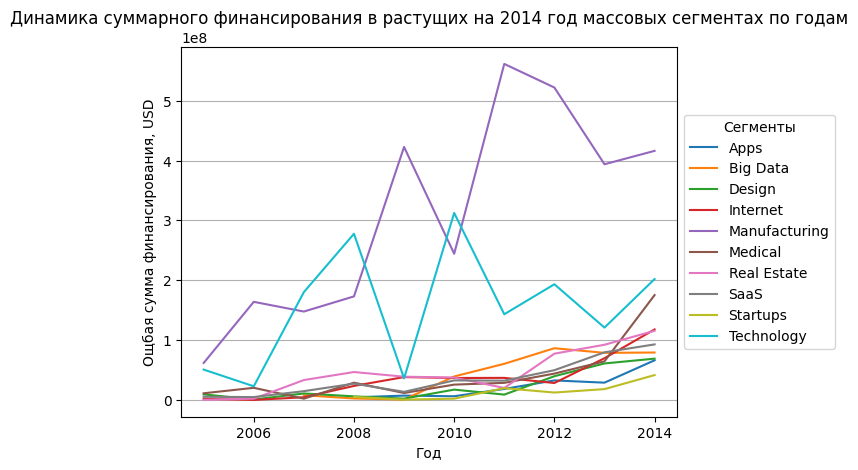

In [117]:
growing_segments_mass_t.loc[2005:].plot.line()

plt.title('Динамика суммарного финансирования в растущих на 2014 год массовых сегментах по годам')
plt.xlabel('Год')
plt.ylabel('Ощбая сумма финансирования, USD')
plt.grid(axis='y')


plt.legend(
    title='Сегменты',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

In [118]:
# уберем с графика выделяющиеся сегменты
cropped = growing_segments_mass_t.loc[2005:, ].drop(columns=['Manufacturing', 'Technology'])
cropped

market,Apps,Big Data,Design,Internet,Medical,Real Estate,SaaS,Startups
funding_year,,,,,,,,
2005,NaN,NaN,9300000.0,1775000.0,11090000.0,250000.0,5240000.0,NaN
2006,1310600.0,NaN,707000.0,5000.0,20250000.0,2080000.0,4791121.0,NaN
2007,NaN,7780000.0,10800000.0,4495379.0,2100000.0,33220000.0,14652595.0,NaN
2008,4300000.0,2452515.0,5944302.0,23412964.0,28812744.0,46613100.0,27226900.0,5010387.0
2009,7219000.0,597375.0,2150144.0,38195773.0,11566200.0,38840213.0,13536585.0,460700.0
2010,6123779.0,39233297.0,17239975.0,36657500.0,25590338.0,37344608.0,32609390.0,2111966.0
2011,18374071.0,60369158.0,8899967.0,36859032.0,28540962.0,20015128.0,32223749.0,19654403.0
2012,32601125.0,86413341.0,39630692.0,28288685.0,44039600.0,77320857.0,49699912.0,12333782.0
2013,28868621.0,78698922.0,60958835.0,69732096.0,64469424.0,92207655.0,79576613.0,18080552.0


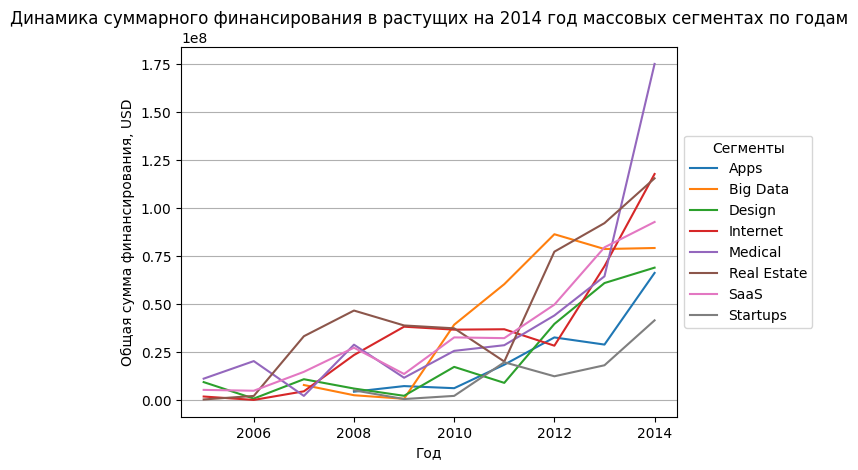

In [119]:
cropped.plot.line()

plt.title('Динамика суммарного финансирования в растущих на 2014 год массовых сегментах по годам')
plt.xlabel('Год')
plt.ylabel('Общая сумма финансирования, USD')
plt.grid(axis='y')


plt.legend(
    title='Сегменты',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

Наиболее быстрый и уверенный рост показывают такие сегменты как Manufacturing и Technology, при этом Manufacturing – явный лидер по суммам фондирования и по их росту, а Technology на втором месте по объему, но в этом сегменте больше волатильность и рост неравномерный (большие колебания, при этом суммы на 2014 год совсем немного выше остальных сегментов).

Среди сегментов с чуть меньшим объемом сумм по скорости роста лидирует сегмент Medical – он показал самый стремительный рост с 2013 по 2014 годы. Сегмент Big Data демонстрировал сильный рост с 2007 по 2012 годы, а затем вышел на "плато". Также заметный рост в последние годы показывают сегменты Internet, Apps и Startups.

График показывает, что после 2010 года особенно сильно выросли инвестиции в сегменты manufacturing, тогда как остальные отрасли росли более умеренно и равномерно. Это указывает на смещение приоритетов инвесторов в сторону производства.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращенные средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

---

In [120]:
df_returns # в миллионах долларов

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00


In [121]:
df[funding_info].head() # в долларах

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19000000.0,0.0,0.0,0.0,0.0,0.0


In [122]:
funding_info_new = funding_info + ['funding_year']

In [123]:
df_investments = df[funding_info_new].groupby('funding_year').sum()
df_investments.style.format("{:.2f}")

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
funding_year,,,,,,,,,,,,,
2000,16759140.00,375362152.00,0.00,215502640.00,0.00,14000000.00,24086333.00,293114.00,0.00,3467747.00,0.00,7718867.00,0.00
2001,26398965.00,285220682.00,0.00,46524067.00,1500000.00,5829217.00,1000000.00,100000.00,0.00,0.00,0.00,0.00,0.00
2002,10465192.00,342362899.00,0.00,42323731.00,0.00,15309671.00,3000000.00,0.00,46441877.00,300000.00,0.00,0.00,0.00
2003,15318355.00,400234425.00,0.00,10280000.00,0.00,1050000.00,5629661.00,16850717.00,0.00,0.00,0.00,0.00,0.00
2004,18104728.00,723016178.00,0.00,98758160.00,0.00,30816623.00,11013741.00,14027534.00,0.00,0.00,0.00,0.00,0.00
2005,39425198.00,4902948129.00,0.00,8871332.00,0.00,101720656.00,60914621.00,6266481.00,5000000.00,4796022.00,0.00,0.00,0.00
2006,66794774.00,9200693515.00,933057.00,71842903.00,11807857.00,140848395.00,70756153.00,6147500.00,35820244.00,0.00,0.00,0.00,0.00
2007,192296481.00,12151591399.00,0.00,109649902.00,14116788.00,657901638.00,201152441.00,34237779.00,195847870.00,12000000.00,0.00,0.00,0.00
2008,302003020.00,14485117900.00,0.00,143785523.00,28600902.00,428622061.00,249299613.00,23485347.00,191756331.00,36000000.00,0.00,0.00,1000000.00


In [124]:
norm = df_returns / (df_investments / 1000000 + 1e-60) * 100 # переводим df_investments в миллионы USD и считаем доли в процентах

In [125]:
norm.style.format("{:.5f}")

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,99.64712,14.75908,0.00000,36.29190,0.00000,61.85714,26.69564,0.00000,0.00000,27.10694,0.00000,2.59105,0.00000
2001,10.90952,8.23573,0.00000,46.21264,0.66667,77.02578,118.00000,0.00000,0.00000,45999999999999999099055916371364748938613639956111999744606208.00000,0.00000,45999999999999999099055916371364748938613639956111999744606208.00000,0.00000
2002,62.97066,61.16901,0.00000,60.88783,2000000000000000255586193770638007998498782384400604241854464.00000,22.33882,113.66667,0.00000,3.25138,113.33333,0.00000,6000000000000000409946658135424053730924854790828028629876736.00000,0.00000
2003,50.52762,58.43076,0.00000,91.43969,1000000000000000127793096885319003999249391192200302120927232.00000,103.80952,60.57203,0.00000,162000000000000036045394392010747369254975544718521659704737792.00000,210999999999999987179814008623678159341900143149586820846583808.00000,0.00000,8000000000000001022344775082552031993995129537602416967417856.00000,0.00000
2004,54.84755,76.88625,0.00000,33.60735,1000000000000000127793096885319003999249391192200302120927232.00000,43.96978,83.35043,0.00000,219000000000000026737846486767146979909616447823557920148160512.00000,338000000000000038555511745943453738306864822252842923629477888.00000,0.00000,55000000000000003638907058515890502445287338128465667741974528.00000,0.00000
2005,67.46954,53.61917,0.00000,107.19923,2000000000000000255586193770638007998498782384400604241854464.00000,34.49644,50.98940,0.00000,48.00000,73.18565,0.00000,5000000000000000460559522838350034863961209779814618556792832.00000,0.00000
2006,92.53718,33.69507,20.36317,65.05862,15.07471,80.37720,67.48530,0.00000,46.53793,2057999999999999865866522894553173325987176074226200066368995328.00000,0.00000,12000000000000000819893316270848107461849709581656057259753472.00000,0.00000
2007,36.61533,29.50535,1000000000000000127793096885319003999249391192200302120927232.00000,50.49708,22.80972,19.10316,81.78375,0.00000,45.34642,203.00000,0.00000,56999999999999990692452094756399610654640903105036260443422720.00000,0.00000
2008,29.70831,18.75732,3000000000000000204973329067712026865462427395414014314938368.00000,28.52860,5.97883,92.74838,41.24756,0.00000,67.99254,234.11111,0.00000,46999999999999998334819205315458827276434300242377841626316800.00000,0.00000


In [126]:
# оставляем только корректные данные, а аномальные заменяем пропусками
norm_new = norm.where(norm <= 1000)

In [127]:
norm_new.style.format("{:.5f}") # значения в процентах

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,99.64712,14.75908,0.00000,36.29190,0.00000,61.85714,26.69564,0.00000,0.00000,27.10694,0.00000,2.59105,0.00000
2001,10.90952,8.23573,0.00000,46.21264,0.66667,77.02578,118.00000,0.00000,0.00000,nan,0.00000,nan,0.00000
2002,62.97066,61.16901,0.00000,60.88783,nan,22.33882,113.66667,0.00000,3.25138,113.33333,0.00000,nan,0.00000
2003,50.52762,58.43076,0.00000,91.43969,nan,103.80952,60.57203,0.00000,nan,nan,0.00000,nan,0.00000
2004,54.84755,76.88625,0.00000,33.60735,nan,43.96978,83.35043,0.00000,nan,nan,0.00000,nan,0.00000
2005,67.46954,53.61917,0.00000,107.19923,nan,34.49644,50.98940,0.00000,48.00000,73.18565,0.00000,nan,0.00000
2006,92.53718,33.69507,20.36317,65.05862,15.07471,80.37720,67.48530,0.00000,46.53793,nan,0.00000,nan,0.00000
2007,36.61533,29.50535,nan,50.49708,22.80972,19.10316,81.78375,0.00000,45.34642,203.00000,0.00000,nan,0.00000
2008,29.70831,18.75732,nan,28.52860,5.97883,92.74838,41.24756,0.00000,67.99254,234.11111,0.00000,nan,0.00000


---
Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

---

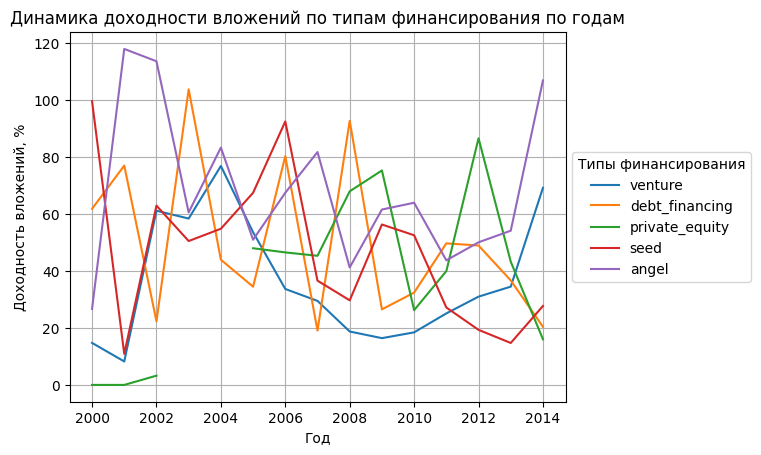

In [128]:
norm_new[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']].plot.line()

plt.title('Динамика доходности вложений по типам финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Доходность вложений, %')
plt.grid(True) 


plt.legend(
    title='Типы финансирования',
    loc='center left',
    bbox_to_anchor=(1, 0.5) # перенос легенды вправо
)

In [129]:
norm_new[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']].agg(['mean', 'median']).T.sort_values(by='mean', ascending=False)

,mean,median
angel,68.286298,61.594542
debt_financing,50.031514,43.969776
seed,46.875596,50.527619
private_equity,38.353025,43.271302
venture,36.653705,31.004291


Динамика доходности довольно разрозненная, определенный тренд на рост или снижение в течение всего рассматриваемого периода однозначно выделить сложно. Однако можно заметить, что с 2013 по 2014 год хороший рост доходности продемонстрировали такие типы финансирования как `angel`, `venture` и `seed`, а сегменты `private_equity` и `debt_financing` показали значительное снижение доходности в последние годы.

Тем не менее, можно выделить тип `angel` как демонстрирующий самую высокую доходность в среднем (несильное снижение в течение периода + заметный рост в последние годы) –  средняя доходность составила 68%. Вторым по средней доходности стал тип `debt_financing` – 50%, затем идет `seed` – 47%. В конце `private_equity` (38%) и `venture` (37%). Но при этом `venture` демонстрирует устойчивый рост доходности с 2007 года, в то время как другие типы характеризуются большей изменчивостью доходности. 

Таким образом, можно выделить `angel` и `venture` как наиболее привлекательные по доходности типы финансирования: 
- Тип `angel` исторически демонстрировал высокую доходность с небольшими колебаниями и продолжает расти с 2011 года, а с 2013 на 2014 доходность возросла на 53 процентных пункта. 

- Тип `venture` резко рос в доходности до 2004 года, затем в период с 2004 по 2007 наблюдалось охлаждение (возможно, в 2004 году был пик популярности этого типа и лопнул некий "пузырь", и к 2007 произошла коррекция), а затем с 2007 года этот тип демонстрирует сильный рост, особенно с 2013 по 2014 – доходность выросла на 35 процентных пунктов.

**Итоги:**

Для каждой компании рассчитали средний объем одного раунда финансирования и построили графики:
- динамики типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;
- динамики общего количества раундов за каждый год (насколько активно происходили инвестиции на рынке – чем больше раундов, тем выше активность).

Определили, что:
- Типичный размер средств, собранных в рамках одного раунда, был максимальным в 2005 году и составлял 4.5 млн долларов.

- Пиковая активность по количеству раундов финансирования за год пришлась на 2013 год – было проведено почти 13 тысяч раундов. В 2014 году общее количество раундов финансирования резко сократилось почти в 2 раза до 7.2 тысяч и опустилась даже ниже уровня 2011 года (хотя до этого все время был рост от года к году). При этом средний объем привлеченных средств в рамках одного раунда немного увеличился в сравнении с 2013 годом и развернул нисходящую тенденцию, длящуюся с 2005 года.


Составили сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Отобрали только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразили, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые достаточно данных, рассматривали только массовые сегменты.

Определили, какие сегменты показывают наиболее быстрый и уверенный рост:

- Наиболее быстрый и уверенный рост показывают такие сегменты как Manufacturing и Technology, при этом Manufacturing – явный лидер по суммам фондирования и по их росту, а Technology на втором месте по объему, но в этом сегменте больше волатильность и рост неравномерный (большие колебания, при этом суммы на 2014 год совсем немного выше остальных сегментов).
- Среди сегментов с чуть меньшим объемом сумм по скорости роста лидирует сегмент Medical – он показал самый стремительный рост с 2013 по 2014 годы. Сегмент Big Data демонстрировал сильный рост с 2007 по 2012 годы, а затем вышел на "плато". Также заметный рост в последние годы показывают сегменты Internet, Apps и Startups.


Для каждого года и каждого вида финансирования рассчитали доходность (какую долю возвращенные средства составляют от предоставленных). 

Построили график, на котором отобразили доходность средств для типов финансирования venture, debt_financing, private_equity, seed и angel.

Сделали вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя:

- Можно выделить тип angel как демонстрирующий самую высокую доходность в среднем (несильное снижение в течение периода + заметный рост в последние годы) – средняя доходность составила 68%. Вторым по средней доходности стал тип debt_financing – 50%, затем идет seed – 47%. В конце private_equity (38%) и venture (37%). Но при этом venture демонстрирует устойчивый рост доходности с 2007 года, в то время как другие типы характеризуются большей изменчивостью доходности.

Таким образом, можно выделить angel и venture как наиболее привлекательные по доходности типы финансирования:

- Тип angel исторически демонстрировал высокую доходность с небольшими колебаниями и продолжает расти с 2011 года, а с 2013 на 2014 доходность возросла на 53 процентных пункта.
- Тип venture резко рос в доходности до 2004 года, затем в период с 2004 по 2007 наблюдалось охлаждение (возможно, в 2004 году был пик популярности этого типа и лопнул некий "пузырь", и к 2007 произошла коррекция), а затем с 2007 года этот тип демонстрирует сильный рост, особенно с 2013 по 2014 – доходность выросла на 35 процентных пунктов.


## Шаг 5. Итоговый вывод и рекомендации

Представим, что на календаре 2015 год. Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

---

### Рекомендации:

По результатам выполненного исследования можно выделить следующие рекомендации для инвесторов:

- **Наиболее привлекательные для инвестирования отрасли** – Manufacturing и Technology (наибольшие объемы фондирования, быстрый и уверенный исторический рост), из сегментов с чуть меньшим объемом финансирования выделяется сегмент Medical (показал самый стремительный рост с 2013 по 2014 годы), из растущих можно также рассмотреть сегменты Internet, Apps и Startups.


- **Наиболее привлекательный тип финансирования** – венчурные инвестиции (наибольший % возвратов и стремительно растущая доходность, наибольший объем финансирования из всех типов, самый популярный и рабочий) и инвестиций от бизнес-ангелов (не сильно популярный, но демонстрирует наибольший % доходности вложений, а также стремительный рост).


### Итоги:

В ходе исследования был проведен анализ исторических данных о финансировании стартапов с целью выявить закономерности и помочь финансовой компании, работающей с венчурными инвестициями, оценить перспективы выхода на рынок с покупкой и развитием компаний.

На первом этапе данные были загружены и подготовлены к анализу: исправлены названия столбцов, приведены к корректному формату типы данных, обработаны пропуски, удалены дубликаты и нерелевантные записи. В результате очистки было удалено около 24,66% исходных данных, что позволило повысить качество и надёжность дальнейшего анализа.

На этапе инжиниринга признаков компании были разделены на группы по длительности финансирования: единичное, до одного года и более года. Выяснилось, что по количеству компаний преобладает единичное финансирование (59,4%), однако по суммарному объему инвестиций лидирует длительное финансирование (61,9%), что указывает на более крупные вложения в долгосрочные проекты. Также компании были сгруппированы по популярности рыночных сегментов на массовые, средние и нишевые: подавляющее большинство относится к массовому сегменту, тогда как средние и нишевые категории представлены значительно меньшим числом компаний.

Далее был проведен анализ выбросов и структуры финансирования. Типичные суммы инвестиций находятся в диапазоне от 0 до 24,5 млн долларов, медиана составляет около 2 млн долларов, а значения выше 25 млн долларов были признаны выбросами и затем исключены из анализа. Наибольшая доля аномально крупных инвестиций наблюдается в сегменте Real Estate. Анализ типов финансирования показал, что венчурные инвестиции являются безусловным лидером как по суммарному объему привлеченных средств (134 млрд долларов), так и по частоте использования. При этом seed-инвестиции часто используются, но имеют сравнительно небольшие суммы. Анализ возвратов средств также подтвердил доминирование venture-финансирования, на которое приходится более 74% всех возвратов.

На этапе анализа динамики рынка было выявлено, что максимальный средний размер одного раунда финансирования наблюдался в 2005 году, тогда как наибольшая активность по количеству раундов пришлась на 2013 год. В 2014 году количество раундов резко сократилось почти вдвое, хотя средний размер инвестиций начал расти. Среди рыночных сегментов наиболее устойчивый рост объёмов финансирования продемонстрировали Manufacturing и Technology, а самый резкий рост в последние годы показал сегмент Medical. Анализ доходности различных типов финансирования показал, что в среднем наиболее высокую доходность демонстрируют angel-инвестиции, тогда как venture-финансирование, несмотря на более низкую среднюю доходность, показывает устойчивый рост показателя с 2007 года.

В целом результаты анализа в значительной степени согласуются между собой: венчурное финансирование является ключевым механизмом инвестирования в стартапы, лидируя по объему, популярности и возвратам. При этом высокая доходность angel-инвестиций может вызывать некоторые сомнения из-за возможной волатильности и меньшего объема данных. Также падение количества раундов в 2014 году на фоне роста среднего размера инвестиций может свидетельствовать о смене структуры рынка — переходе к более крупным, но менее частым инвестиционным сделкам.